# Projet 1 — Audit quantitatif et analyse de style d'un fonds
## Fonds étudié : Fidelity Magellan Fund (FMAGX) — Modèle de Fama–French à 3 facteurs (et extension Carhart)

**Groupe 5** — Économétrie appliquée à la finance

---

### Plan du notebook (déroulé méthodologique imposé)

| Étape | Section du notebook |
|---|---|
| 1. Présentation du problème et des objectifs | 1 |
| 2. Collecte des données (traçabilité) | 2 |
| 3. Construction des variables | 3 |
| 4. Prétraitement (valeurs manquantes, valeurs aberrantes IQR) | 4 |
| 5. Analyse exploratoire (stats descriptives, histogrammes, corrélations, Jarque–Bera) | 5 |
| 6. Modélisation (MCO multiple, `statsmodels.api.OLS`) | 6 |
| 7. Validation et diagnostic (VIF, Breusch–Pagan, White HC1, normalité, Cook) | 7 |
| 8. Interprétation sur un échantillon jamais utilisé pour l'estimation | 8 |
| Pour aller plus loin : Carhart 4 facteurs (R² ajusté, BIC) + robustesse | 9 – 10 |
| 9. Bilan critique | 11 |
| Export des résidus pour le Projet 2 | 12 |

## 1. Présentation du problème et des objectifs

### 1.1 La question économique

Un fonds à **gestion active** facture des frais plus élevés qu'un fonds indiciel, au motif que son gérant saurait
**sélectionner** des titres mieux que le marché. Mais un fonds peut afficher une belle performance simplement parce
qu'il est **exposé à des facteurs de risque** qui ont été rémunérés sur la période : le marché dans son ensemble,
les petites capitalisations (*small caps*) ou au contraire les grandes, les valeurs décotées (*value*) ou au contraire
les valeurs de croissance (*growth*). Ces expositions peuvent être répliquées **à bas coût** avec des ETF factoriels :
elles ne justifient donc pas des frais de gestion active.

> **Question posée :** la performance historique du *Fidelity Magellan Fund* (FMAGX) sur les 5 dernières années
> provient-elle d'un **réel talent de sélection** du gérant (un alpha de Jensen $\alpha_i$ significativement positif),
> ou s'explique-t-elle **entièrement par son exposition passive** aux facteurs de risque systématiques
> (marché, taille, style value/growth) ?

### 1.2 Pour qui cette régression a-t-elle un sens ?

* **Un investisseur particulier ou un conseiller en gestion de patrimoine** qui hésite entre FMAGX et un ETF
  « S&P 500 Growth » bien moins cher : si $\alpha_i \le 0$, il paie des frais actifs pour une exposition qu'il pourrait
  répliquer passivement.
* **Un sélectionneur de fonds / un comité d'investissement** (fonds de fonds, assureur, caisse de retraite) qui doit
  **auditer** un gérant : l'analyse de style vérifie que le fonds fait bien ce qu'il annonce (un fonds « large cap
  diversifié » ne devrait pas être massivement exposé aux *small caps*) et détecte d'éventuelles **dérives de style**.
* **Un risk manager** : les bêtas factoriels donnent la sensibilité du fonds aux chocs de marché, de taille et de style,
  donc la manière dont il se comportera dans un scénario de stress.

### 1.3 Le modèle

Le modèle à trois facteurs de Fama et French (1993), présenté au chapitre 3, s'écrit :

$$
R_{it} - R_{ft} = \alpha_i + \beta_{i1}\,(R_{mt} - R_{ft}) + \beta_{i2}\,SMB_t + \beta_{i3}\,HML_t + \varepsilon_{it}
$$

| Terme | Signification | Lecture attendue |
|---|---|---|
| $R_{it} - R_{ft}$ | excès de rendement mensuel du fonds sur le taux sans risque | variable expliquée $y_t$ |
| $\alpha_i$ | **alpha de Jensen** : rendement moyen non expliqué par les facteurs | $>0$ et significatif ⇒ talent ; $\approx 0$ ⇒ pas de valeur ajoutée ; $<0$ ⇒ destruction de valeur (frais) |
| $\beta_{i1}$ | sensibilité au marché | $>1$ fonds agressif, $<1$ défensif |
| $\beta_{i2}$ | exposition au facteur taille *Small Minus Big* | $>0$ biais *small caps*, $<0$ biais *large caps* |
| $\beta_{i3}$ | exposition au facteur *High Minus Low* (book-to-market) | $>0$ biais *value*, $<0$ biais *growth* |
| $\varepsilon_{it}$ | risque spécifique (idiosyncratique) | bruit blanc de moyenne nulle sous les hypothèses MCO |

**Hypothèses de travail.** Nous testerons au seuil de **5 %** :
$H_0 : \alpha_i = 0$ (pas de talent) contre $H_1 : \alpha_i \neq 0$.

### 1.4 Pourquoi FMAGX ?
Le *Fidelity Magellan Fund* est l'un des fonds actions américains à gestion active les plus célèbres (géré par Peter Lynch
de 1977 à 1990). Il est présenté comme un fonds **large cap diversifié**, dispose d'un historique de cours très long sur
Yahoo Finance et est bien un fonds **actif** (non indiciel) : il satisfait donc les critères de l'énoncé.

## 0. Environnement technique

Bibliothèques utilisées :
* `yfinance` : téléchargement des cours du fonds depuis Yahoo Finance ;
* `pandas_datareader` : facteurs Fama–French (Kenneth French Data Library) et taux FRED ;
* `statsmodels` : régressions MCO (`statsmodels.api.OLS`), tests de diagnostic (Breusch–Pagan, White, VIF, Cook) ;
* `scipy.stats` : moments empiriques et test de Jarque–Bera ;
* `matplotlib` : graphiques.

Tous les paramètres de l'étude (fonds, période, seuil) sont regroupés dans une seule cellule afin que l'analyse soit
**entièrement reproductible** et facile à relancer sur un autre fonds.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader
import pandas_datareader.data as web
import statsmodels
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Style graphique sobre et lisible ---
COLORS = {"fonds": "#2a78d6", "marche": "#eb6834", "autre": "#1baf7a", "gris": "#8a8984", "rouge": "#e34948"}
plt.rcParams.update({
    "figure.figsize": (10, 4.5), "figure.dpi": 100,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 2,
    "legend.frameon": False,
})
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.width", 140)

for lib in (pd, np, yf, pandas_datareader, statsmodels):
    print(f"{lib.__name__:<18} {lib.__version__}")

pandas             3.0.3
numpy              2.4.6
yfinance           1.7.0
pandas_datareader  0.11.1
statsmodels        0.14.6


In [2]:
# ======================= PARAMÈTRES DE L'ÉTUDE =======================
TICKER     = "FMAGX"                     # symbole Yahoo Finance du fonds
FUND_NAME  = "Fidelity Magellan Fund"
START_M    = "2021-08"                   # premier mois de rendement de l'échantillon
END_M      = "2026-07"                   # dernier mois publié par K. French à la date du travail
N_TEST     = 12                          # nb de mois gardés hors échantillon (section 8)
SEUIL      = 0.05                        # seuil des tests
DATA_DIR   = Path("data")                # dossier de sauvegarde des données brutes (traçabilité)
DATA_DIR.mkdir(exist_ok=True)

periods = pd.period_range(START_M, END_M, freq="M")
print(f"Période d'étude : {periods[0]} -> {periods[-1]}  ({len(periods)} mois = {len(periods)/12:.0f} ans)")

Période d'étude : 2021-08 -> 2026-07  (60 mois = 5 ans)


## 2. Collecte des données

### 2.1 Sources et traçabilité

| Série | Source exacte | Code / symbole | Fréquence brute | Unité brute | Usage |
|---|---|---|---|---|---|
| Cours du fonds | Yahoo Finance via `yfinance` | `FMAGX` | quotidienne (VL) | USD | rendement $R_{it}$ |
| Marché, SMB, HML, taux sans risque | Kenneth French Data Library via `pandas_datareader` | `F-F_Research_Data_Factors` | mensuelle | % | $R_{mt}-R_{ft}$, $SMB_t$, $HML_t$, $R_{ft}$ |
| Momentum | Kenneth French Data Library via `pandas_datareader` | `F-F_Momentum_Factor` | mensuelle | % | $MOM_t$ (Carhart, §9) |
| Taux sans risque alternatif | FRED (Fed de St-Louis) via `pandas_datareader` | `DTB3` | quotidienne | % annualisé | robustesse (§10) |

URL de la Kenneth French Data Library : <https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html>
— URL FRED : <https://fred.stlouisfed.org/series/DTB3> — URL Yahoo : <https://finance.yahoo.com/quote/FMAGX/history>

### 2.2 Choix techniques importants pour le fonds

1. **Cours ajusté des distributions.** Un fonds commun de placement américain distribue chaque année des dividendes et
   surtout des **plus-values réalisées** (*capital gains distributions*), en général en décembre. Le jour de la
   distribution, la valeur liquidative (VL) baisse mécaniquement du montant distribué, **sans aucune perte pour
   l'investisseur**. Utiliser le cours brut créerait donc de faux rendements négatifs. Nous téléchargeons à la fois le
   cours brut (`Close`) et le cours ajusté (`Adj Close`), et nous utilisons **le cours ajusté** (équivalent de
   `auto_adjust=True`). La comparaison des deux est faite au §4.3.
2. **Données quotidiennes ramenées en fin de mois.** Plutôt que l'option `interval="1mo"` de Yahoo (dont les barres sont
   datées au 1ᵉʳ du mois et dont le dernier mois peut être incomplet), nous téléchargeons les VL quotidiennes et nous
   retenons la **dernière VL de chaque mois civil** (`resample("ME").last()`). C'est exactement la convention des facteurs
   de Ken French (rendement du dernier jour ouvré du mois $t-1$ au dernier jour ouvré du mois $t$).
3. **Sauvegarde locale.** Les séries brutes sont enregistrées en CSV dans `data/` avec la date d'extraction : le rapport
   peut ainsi citer précisément les données utilisées, même si Yahoo ou K. French révisent leurs séries plus tard.

In [3]:
extraction = datetime.now().strftime("%Y-%m-%d %H:%M")
first_p, last_p = periods[0], periods[-1]

# ---------- 1) Fonds : VL quotidiennes (brutes et ajustées) ----------
dl_start = (first_p - 2).start_time.strftime("%Y-%m-%d")        # marge de 2 mois pour avoir P_{t-1}
dl_end   = ((last_p + 1).start_time + pd.Timedelta(days=7)).strftime("%Y-%m-%d")
px = yf.download(TICKER, start=dl_start, end=dl_end, auto_adjust=False, progress=False)
if isinstance(px.columns, pd.MultiIndex):                          # yfinance >= 0.2 : colonnes (champ, ticker)
    px = px.xs(TICKER, axis=1, level=1)
daily = px[["Close", "Adj Close"]].rename(columns={"Close": "close_brut", "Adj Close": "close_ajuste"})
daily.to_csv(DATA_DIR / f"{TICKER}_quotidien.csv")

# ---------- 2) Facteurs Fama-French 3 facteurs + momentum ----------
ff_raw  = web.DataReader("F-F_Research_Data_Factors", "famafrench", start=dl_start)[0]
mom_raw = web.DataReader("F-F_Momentum_Factor", "famafrench", start=dl_start)[0]
ff_raw.to_csv(DATA_DIR / "FF_Research_Data_Factors_mensuel.csv")
mom_raw.to_csv(DATA_DIR / "FF_Momentum_Factor_mensuel.csv")

# ---------- 3) Taux sans risque alternatif FRED DTB3 ----------
dtb3_raw = web.DataReader("DTB3", "fred", start=dl_start, end=dl_end)
dtb3_raw.to_csv(DATA_DIR / "FRED_DTB3_quotidien.csv")

trace = pd.DataFrame({
    "source": ["Yahoo Finance (yfinance)", "K. French Data Library", "K. French Data Library", "FRED"],
    "série":  [f"{TICKER} Close / Adj Close", "F-F_Research_Data_Factors", "F-F_Momentum_Factor", "DTB3"],
    "fréquence": ["quotidienne", "mensuelle", "mensuelle", "quotidienne"],
    "première date": [daily.index.min().date(), ff_raw.index.min(), mom_raw.index.min(), dtb3_raw.index.min().date()],
    "dernière date": [daily.index.max().date(), ff_raw.index.max(), mom_raw.index.max(), dtb3_raw.index.max().date()],
    "nb obs.": [len(daily), len(ff_raw), len(mom_raw), len(dtb3_raw)],
})
print(f"Extraction réalisée le {extraction}\n")
trace

Extraction réalisée le 2026-09-25 11:39



,source,série,fréquence,première date,dernière date,nb obs.
0,Yahoo Finance (yfinance),FMAGX Close / Adj Close,quotidienne,2021-06-01,2026-08-07,1303
1,K. French Data Library,F-F_Research_Data_Factors,mensuelle,2021-06,2026-07,62
2,K. French Data Library,F-F_Momentum_Factor,mensuelle,2021-06,2026-07,62
3,FRED,DTB3,quotidienne,2021-06-01,2026-08-07,1354


In [4]:
print("Colonnes Fama-French :", ff_raw.columns.tolist(), "| Momentum :", mom_raw.columns.tolist())
print("\nDernières observations des facteurs (en %) :")
display(pd.concat([ff_raw, mom_raw], axis=1).tail(4))
print("Dernières VL quotidiennes du fonds :")
display(daily.tail(4))

Colonnes Fama-French : ['Mkt-RF', 'SMB', 'HML', 'RF'] | Momentum : ['Mom']

Dernières observations des facteurs (en %) :


,Mkt-RF,SMB,HML,RF,Mom
Date,,,,,
2026-04,9.9500,0.1900,-1.3700,0.2900,9.5100
2026-05,4.9100,-1.5900,-2.3100,0.3100,1.3900
2026-06,-1.0700,3.3900,3.5800,0.2900,4.6200
2026-07,-0.6000,-1.9600,2.1100,0.3300,-12.2500


Dernières VL quotidiennes du fonds :


Price,close_brut,close_ajuste
Date,,
2026-08-04,15.9300,15.9300
2026-08-05,15.9000,15.9000
2026-08-06,15.8700,15.8700
2026-08-07,15.9000,15.9000


**Remarque sur la période.** À la date du travail, la Kenneth French Data Library publie les facteurs jusqu'à
**juillet 2026** (publication avec environ deux mois de décalage). La fenêtre de 5 ans retenue va donc d'**août 2021 à
juillet 2026**, soit **60 rendements mensuels**. Le cours de fin juillet 2021 sert uniquement de point de départ au
premier rendement.

## 3. Construction des variables

### 3.1 Rendement du fonds : log-rendement mensuel
Conformément à l'énoncé et au chapitre 1, on utilise le **log-rendement** :
$$ r_{it} = \ln\!\left(\frac{P_{t}}{P_{t-1}}\right) $$
où $P_t$ est la VL **ajustée** du dernier jour ouvré du mois $t$. Les log-rendements sont **additifs dans le temps**
(le rendement sur $n$ mois est la somme des rendements mensuels), ce qui est commode, et leur distribution est plus
symétrique que celle des rendements arithmétiques.

### 3.2 Facteurs
Les facteurs de K. French sont publiés **en pourcentage** : on les divise par 100.
* `MKT_RF` $= R_{mt} - R_{ft}$ : rendement du marché américain (toutes les actions NYSE, AMEX, NASDAQ, pondérées par la
  capitalisation) moins le taux sans risque ;
* `SMB` : rendement d'un portefeuille long petites capitalisations / court grandes capitalisations ;
* `HML` : rendement d'un portefeuille long fort *book-to-market* (value) / court faible *book-to-market* (growth) ;
* `RF` : rendement mensuel du bon du Trésor américain à 1 mois ;
* `MOM` : rendement long « gagnants des 12 derniers mois » / court « perdants » (utilisé au §9).

### 3.3 Excès de rendement (ajustement au taux sans risque)
$$ y_t = r_{it} - R_{ft} $$

> ⚠️ **Point de cohérence à garder en tête.** Les facteurs de K. French sont des rendements **arithmétiques** (simples),
> alors que $r_{it}$ est un **log**-rendement. Or $\ln(1+R) \approx R - \sigma^2/2$ en moyenne : le log-rendement moyen
> d'un actif volatil est **inférieur** à son rendement arithmétique moyen. Mécaniquement, cela tire l'alpha estimé vers
> le bas d'environ $\sigma_i^2/2$ par mois. Nous suivons la consigne (log-rendements) pour le modèle principal, mais nous
> mesurons l'ampleur de ce biais au §10.2 en ré-estimant le modèle avec des rendements simples.

In [5]:
# --- Prix de fin de mois (dernière VL du mois civil) ---
monthly = daily.resample("ME").last()
monthly.index = monthly.index.to_period("M")

# --- Log-rendements (ajusté = variable du modèle ; brut = pour le contrôle du §4.3) ---
rets = pd.DataFrame({
    "r_fonds":      np.log(monthly["close_ajuste"] / monthly["close_ajuste"].shift(1)),
    "r_fonds_brut": np.log(monthly["close_brut"]   / monthly["close_brut"].shift(1)),
    "R_fonds_simple": monthly["close_ajuste"].pct_change(),          # rendement simple (robustesse §10.2)
})

# --- Facteurs en décimal, noms de colonnes explicites ---
ff = (ff_raw / 100).rename(columns={"Mkt-RF": "MKT_RF"})
mom = (mom_raw / 100).rename(columns={mom_raw.columns[0]: "MOM"})

# --- Taux FRED DTB3 : taux annualisé en %, converti en taux mensuel. On retient la dernière valeur connue
#     à la fin du mois t-1 (taux connu au début du mois t, comme le RF de K. French). ---
dtb3_m = dtb3_raw["DTB3"].resample("ME").last()
dtb3_m.index = dtb3_m.index.to_period("M")
rf_fred = (dtb3_m.shift(1) / 100 / 12).rename("RF_FRED")

# --- Fusion alignée sur les mois de l'étude (jointure sur un index mensuel commun) ---
data = pd.concat([rets, ff, mom, rf_fred], axis=1).reindex(periods)
data["y"] = data["r_fonds"] - data["RF"]                      # excès de rendement du fonds
data["MKT"] = data["MKT_RF"] + data["RF"]                     # rendement total du marché (pour les graphiques)

FACTORS3 = ["MKT_RF", "SMB", "HML"]
FACTORS4 = FACTORS3 + ["MOM"]
data[["r_fonds", "RF", "y"] + FACTORS4].head()

,r_fonds,RF,y,MKT_RF,SMB,HML,MOM
2021-08,0.0360,0.0000,0.0360,0.0294,-0.0032,-0.0023,0.0263
2021-09,-0.0562,0.0000,-0.0562,-0.0440,0.0066,0.0512,0.0143
2021-10,0.0812,0.0000,0.0812,0.0663,-0.0226,-0.0053,0.0331
2021-11,0.0097,0.0000,0.0097,-0.0158,-0.0131,-0.0037,0.0096
2021-12,0.0185,0.0001,0.0184,0.0323,-0.0163,0.0325,-0.0240


## 4. Prétraitement

### 4.1 Valeurs manquantes
L'énoncé demande de **documenter** les valeurs manquantes plutôt que de les supprimer en silence. On contrôle
successivement : (i) les données quotidiennes brutes, (ii) la couverture mensuelle (chaque mois de l'étude a-t-il au moins
une VL ?), (iii) le panel mensuel final.

In [6]:
# (i) Données quotidiennes du fonds
print("=== (i) VL quotidiennes FMAGX ===")
print("Valeurs manquantes par colonne :", daily.isna().sum().to_dict())
jours = daily.loc[str(first_p - 1):str(last_p)].groupby(daily.loc[str(first_p - 1):str(last_p)].index.to_period("M")).size()
print(f"Nombre de VL par mois : min = {jours.min()}, max = {jours.max()}, moyenne = {jours.mean():.1f}")
print("Mois avec moins de 18 VL :", jours[jours < 18].index.astype(str).tolist() or "aucun")

# (ii) FRED DTB3 : série quotidienne avec des jours sans cotation
nan_fred = dtb3_raw["DTB3"].isna()
print("\n=== (ii) FRED DTB3 (quotidien) ===")
print(f"{nan_fred.sum()} valeurs manquantes sur {len(nan_fred)} jours, par ex. :",
      dtb3_raw.index[nan_fred][:5].strftime("%Y-%m-%d").tolist())

# (iii) Panel mensuel final
print("\n=== (iii) Panel mensuel final (60 mois attendus) ===")
na_tab = data.isna().sum().to_frame("nb NaN")
na_tab["mois concernés"] = [", ".join(data.index[data[c].isna()].astype(str)) for c in data.columns]
na_tab

=== (i) VL quotidiennes FMAGX ===
Valeurs manquantes par colonne : {'close_brut': 0, 'close_ajuste': 0}
Nombre de VL par mois : min = 19, max = 23, moyenne = 20.9
Mois avec moins de 18 VL : aucun

=== (ii) FRED DTB3 (quotidien) ===
57 valeurs manquantes sur 1354 jours, par ex. : ['2021-07-05', '2021-09-06', '2021-10-11', '2021-11-11', '2021-11-25']

=== (iii) Panel mensuel final (60 mois attendus) ===


,nb NaN,mois concernés
r_fonds,0,
r_fonds_brut,0,
R_fonds_simple,0,
MKT_RF,0,
SMB,0,
HML,0,
RF,0,
MOM,0,
RF_FRED,0,
y,0,


**Bilan des valeurs manquantes.**
* Les VL quotidiennes du fonds sont complètes : chaque mois contient une vingtaine de VL, la dernière VL du mois est
  donc toujours disponible. **Aucune imputation n'est nécessaire.**
* La série FRED `DTB3` contient des valeurs manquantes : ce sont les **jours fériés fédéraux américains** (marché
  obligataire fermé), pas des erreurs. Elles n'ont aucune conséquence car on ne retient que la **dernière valeur
  disponible** de chaque mois (`resample("ME").last()` ignore les NaN). Elles sont conservées telles quelles dans le
  fichier brut sauvegardé.
* Le panel mensuel final de 60 observations ne contient **aucune valeur manquante** : l'échantillon d'estimation n'a
  donc subi **aucune suppression de ligne**.

### 4.2 Valeurs aberrantes — méthode IQR (§3.6.3)

Une observation $x$ est signalée comme atypique si elle sort de l'intervalle
$$ [\,Q_1 - 1{,}5 \times IQR \;;\; Q_3 + 1{,}5 \times IQR\,], \qquad IQR = Q_3 - Q_1 .$$

La règle IQR ne dit pas *quoi faire* d'un point atypique : on doit distinguer une **erreur de données** (à corriger) d'un
**événement de marché réel** (à conserver, car c'est précisément l'information que le modèle doit expliquer).

In [7]:
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return lo, hi, s[(s < lo) | (s > hi)]

cols_iqr = ["r_fonds", "y"] + FACTORS4
rows, flagged = [], {}
for c in cols_iqr:
    lo, hi, out = iqr_outliers(data[c])
    flagged[c] = out
    rows.append({"variable": c, "borne basse": lo, "borne haute": hi, "nb atypiques": len(out),
                 "mois (valeur)": ", ".join(f"{p} ({v:+.2%})" for p, v in out.items()) or "-"})
iqr_table = pd.DataFrame(rows).set_index("variable")
iqr_table

,borne basse,borne haute,nb atypiques,mois (valeur)
variable,,,,
r_fonds,-0.1199,0.1384,0,-
y,-0.1227,0.1342,0,-
MKT_RF,-0.1139,0.1263,0,-
SMB,-0.0692,0.0542,2,"2023-12 (+6.28%), 2024-07 (+6.81%)"
HML,-0.0876,0.1047,2,"2022-01 (+12.86%), 2023-03 (-9.05%)"
MOM,-0.0868,0.0991,2,"2023-01 (-16.21%), 2026-07 (-12.25%)"


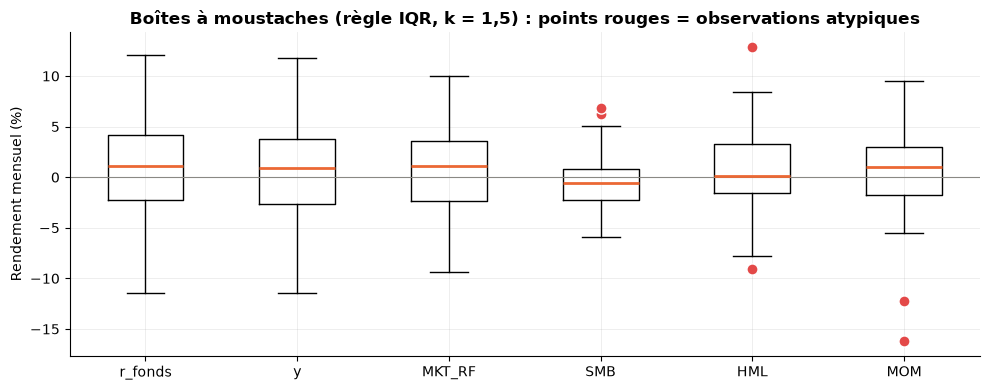

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot([data[c] * 100 for c in cols_iqr], whis=1.5, widths=0.5,
           medianprops=dict(color=COLORS["marche"], linewidth=2),
           flierprops=dict(marker="o", markerfacecolor=COLORS["rouge"], markeredgecolor="white", markersize=8))
ax.set_xticks(range(1, len(cols_iqr) + 1), cols_iqr)
ax.axhline(0, color=COLORS["gris"], lw=0.8)
ax.set_ylabel("Rendement mensuel (%)")
ax.set_title("Boîtes à moustaches (règle IQR, k = 1,5) : points rouges = observations atypiques")
plt.tight_layout(); plt.show()

**Lecture de la règle IQR.**
* **Le fonds (`r_fonds`, `y`) et le marché (`MKT_RF`) ne présentent aucune valeur atypique** au sens de l'IQR : sur la
  période, même les mois les plus violents (environ −11 % et +12 % pour le fonds) restent dans les moustaches.
* Les valeurs signalées concernent **uniquement les facteurs de style**, et chacune correspond à un **épisode de marché
  identifiable**, pas à une erreur de saisie :
  * **HML janvier 2022 (+12,9 %)** : la Fed annonce la remontée des taux, et on observe une rotation brutale des valeurs de croissance
    vers les valeurs décotées ;
  * **HML mars 2023 (−9,1 %)** : crise des banques régionales américaines (SVB), qui pèsent lourd dans le portefeuille *value* ;
  * **SMB décembre 2023 (+6,3 %) et juillet 2024 (+6,8 %)** : rebonds des petites capitalisations sur l'anticipation de
    baisses de taux ;
  * **MOM janvier 2023 (−16,2 %) et juillet 2026 (−12,3 %)** : *momentum crashes*, c'est-à-dire des retournements brutaux où les
    perdants récents rebondissent. C'est un phénomène bien documenté (Daniel et Moskowitz, 2016).

**Décision : on conserve toutes les observations.** Ce sont des facteurs officiels, calculés par K. French à partir de
l'ensemble du marché américain, et ces mois extrêmes sont précisément les chocs de risque que le modèle doit expliquer.
Les supprimer reviendrait à « lisser » artificiellement le risque du fonds. En revanche, on vérifiera au §7.4 (distance
de Cook) si ces mois **pilotent** l'estimation, ce qui est la bonne question économétrique.

### 4.3 Contrôle de cohérence : pourquoi le cours **ajusté** est indispensable

On compare les log-rendements calculés à partir de la VL brute et de la VL ajustée. Les mois où l'écart est important
correspondent aux **distributions de plus-values et de dividendes** du fonds.

Mois où l'écart ajusté - brut dépasse 0,5 point de % :


,r ajusté,r brut,écart
2021-12,0.0185,-0.0104,0.0289
2022-05,-0.0084,-0.0471,0.0387
2022-12,-0.0684,-0.0756,0.0072
2023-05,0.0189,-0.0942,0.1131
2023-12,0.0433,0.0272,0.0161
2024-05,0.0439,0.0137,0.0302
2024-12,-0.0293,-0.0602,0.0309
2025-05,0.0848,0.0370,0.0478
2025-12,-0.0106,-0.0553,0.0447
2026-05,0.0284,0.0077,0.0207


Avec le cours BRUT, la règle IQR signalerait 0 mois atypique(s) : []
Rendement annualisé moyen : ajusté = +8.83%, brut = +1.26%


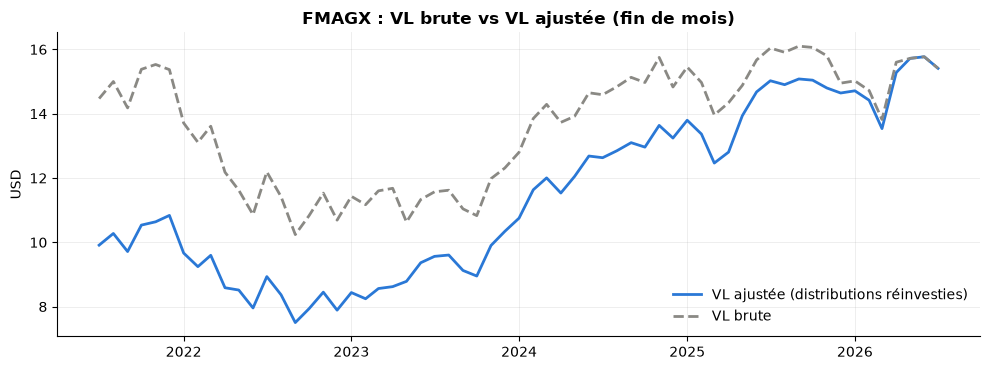

In [9]:
ecart = (data["r_fonds"] - data["r_fonds_brut"])
comp = pd.DataFrame({"r ajusté": data["r_fonds"], "r brut": data["r_fonds_brut"], "écart": ecart})
print("Mois où l'écart ajusté - brut dépasse 0,5 point de % :")
display(comp[ecart.abs() > 0.005])

lo, hi, out_brut = iqr_outliers(data["r_fonds_brut"])
print(f"Avec le cours BRUT, la règle IQR signalerait {len(out_brut)} mois atypique(s) :",
      [f"{p} ({v:+.2%})" for p, v in out_brut.items()])
print(f"Rendement annualisé moyen : ajusté = {data['r_fonds'].mean()*12:+.2%}, brut = {data['r_fonds_brut'].mean()*12:+.2%}")

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(monthly.loc[first_p - 1:last_p].index.to_timestamp(), monthly.loc[first_p - 1:last_p, "close_ajuste"],
        color=COLORS["fonds"], label="VL ajustée (distributions réinvesties)")
ax.plot(monthly.loc[first_p - 1:last_p].index.to_timestamp(), monthly.loc[first_p - 1:last_p, "close_brut"],
        color=COLORS["gris"], ls="--", label="VL brute")
ax.set_ylabel("USD"); ax.set_title("FMAGX : VL brute vs VL ajustée (fin de mois)"); ax.legend()
plt.tight_layout(); plt.show()

**Pourquoi c'est crucial.** L'écart entre rendement brut et ajusté apparaît **chaque année en mai et en décembre**, qui
sont les mois de distribution du fonds. Il atteint **+11,3 points en mai 2023** (−9,4 % en brut contre +1,9 % en réalité).
Au total, le rendement annualisé moyen serait de **+1,3 %** avec le cours brut, contre **+8,8 %** avec le cours
ajusté : **utiliser le cours brut sous-estimerait la performance d'environ 7,5 points par an**, et donc l'alpha d'autant.
Ce serait une erreur d'audit majeure.

On note aussi que la règle IQR **ne détecte aucune** de ces fausses baisses : elles restent noyées dans la volatilité
normale du fonds. Une méthode statistique de détection des valeurs aberrantes ne remplace donc pas la **connaissance du
processus qui génère les données** (ici, le mécanisme des distributions des fonds américains).

## 5. Analyse exploratoire

### 5.1 Statistiques descriptives et test de Jarque–Bera (chapitre 1)

Pour chaque série on calcule la moyenne, l'écart-type (mensuels puis annualisés : $\times 12$ et $\times\sqrt{12}$), la
**skewness** (asymétrie, 0 pour une loi normale) et la **kurtosis** (aplatissement, 3 pour une loi normale ; on affiche
aussi l'excès de kurtosis $K-3$).

Le **test de Jarque–Bera** teste conjointement $H_0$ : « skewness $=0$ et kurtosis $=3$ » (normalité) :
$$ JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right) \;\sim\; \chi^2(2) \text{ sous } H_0 .$$
On rejette la normalité si la p-value est inférieure à 5 %.

In [10]:
def describe_series(s):
    s = s.dropna()
    jb = stats.jarque_bera(s)
    return pd.Series({
        "n": len(s),
        "moyenne (mens.)": s.mean(),
        "écart-type (mens.)": s.std(ddof=1),
        "moyenne annualisée": s.mean() * 12,
        "volatilité annualisée": s.std(ddof=1) * np.sqrt(12),
        "min": s.min(), "max": s.max(),
        "skewness": stats.skew(s),
        "kurtosis": stats.kurtosis(s, fisher=False),
        "excès de kurtosis": stats.kurtosis(s, fisher=True),
        "Jarque-Bera": jb.statistic,
        "p-value JB": jb.pvalue,
        "normalité rejetée (5%)": "oui" if jb.pvalue < SEUIL else "non",
    })

desc = pd.DataFrame({c: describe_series(data[c]) for c in ["r_fonds", "y", "MKT", "MKT_RF", "SMB", "HML", "MOM", "RF"]})
desc

,r_fonds,y,MKT,MKT_RF,SMB,HML,MOM,RF
n,60,60,60,60,60,60,60,60
moyenne (mens.),0.0074,0.0044,0.0104,0.0074,-0.0046,0.0064,0.0051,0.0029
écart-type (mens.),0.0534,0.0530,0.0467,0.0464,0.0274,0.0388,0.0406,0.0015
moyenne annualisée,0.0883,0.0530,0.1245,0.0892,-0.0552,0.0763,0.0616,0.0353
volatilité annualisée,0.1849,0.1837,0.1619,0.1607,0.0948,0.1345,0.1405,0.0053
min,-0.1143,-0.1143,-0.0941,-0.0941,-0.0593,-0.0905,-0.1621,0.0000
max,0.1212,0.1183,0.1024,0.0995,0.0681,0.1286,0.0951,0.0048
skewness,-0.2274,-0.1895,-0.2334,-0.2010,0.4032,0.3022,-1.4803,-0.9700
kurtosis,2.8235,2.8012,2.5584,2.5378,3.2660,3.8622,7.5573,2.5913
excès de kurtosis,-0.1765,-0.1988,-0.4416,-0.4622,0.2660,0.8622,4.5573,-0.4087


Performance cumulée sur 5 ans : FMAGX = +55.5% | Marché US (Mkt) = +74.3%
Ratio de Sharpe annualisé      : FMAGX = 0.29  | Marché US       = 0.56
Bêta 'naïf' (cov/var)          : 1.087


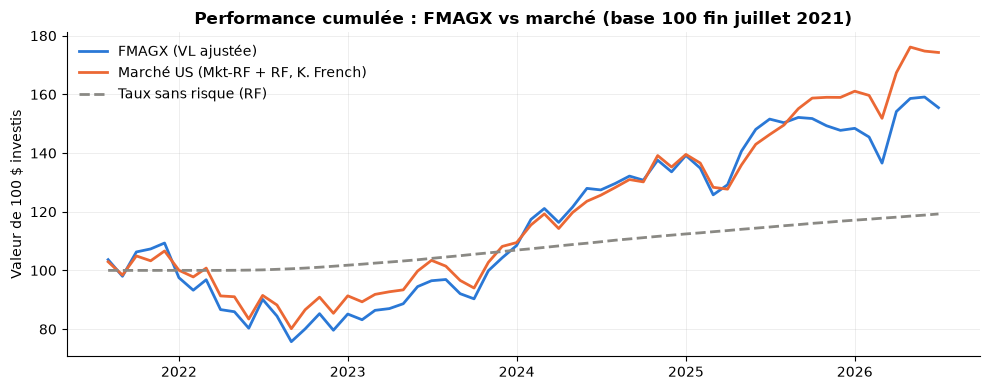

In [11]:
# Ratio de Sharpe annualisé (lecture « audit ») : excès de rendement moyen / volatilité
sharpe_fonds  = data["y"].mean() / data["y"].std() * np.sqrt(12)
sharpe_marche = data["MKT_RF"].mean() / data["MKT_RF"].std() * np.sqrt(12)
cum_fonds  = np.exp(data["r_fonds"].sum()) - 1
cum_marche = (1 + data["MKT"]).prod() - 1
print(f"Performance cumulée sur 5 ans : FMAGX = {cum_fonds:+.1%} | Marché US (Mkt) = {cum_marche:+.1%}")
print(f"Ratio de Sharpe annualisé      : FMAGX = {sharpe_fonds:.2f}  | Marché US       = {sharpe_marche:.2f}")
print(f"Bêta 'naïf' (cov/var)          : {data[['y','MKT_RF']].cov().iloc[0,1] / data['MKT_RF'].var():.3f}")

fig, ax = plt.subplots(figsize=(10, 4))
t = data.index.to_timestamp()
ax.plot(t, 100 * np.exp(data["r_fonds"].cumsum()), color=COLORS["fonds"], label=f"{TICKER} (VL ajustée)")
ax.plot(t, 100 * (1 + data["MKT"]).cumprod(), color=COLORS["marche"], label="Marché US (Mkt-RF + RF, K. French)")
ax.plot(t, 100 * (1 + data["RF"]).cumprod(), color=COLORS["gris"], ls="--", label="Taux sans risque (RF)")
ax.set_ylabel("Valeur de 100 $ investis"); ax.set_title("Performance cumulée : FMAGX vs marché (base 100 fin juillet 2021)")
ax.legend(); plt.tight_layout(); plt.show()

**Lecture des statistiques descriptives.**
* **Performance brute décevante.** Sur 5 ans, FMAGX progresse de **+55,5 %**, contre **+74,3 %** pour le marché
  américain. Son excès de rendement moyen est de 5,3 %/an pour une volatilité de 18,4 %/an. Il est donc **plus volatil que le
  marché** (16,1 %/an) tout en rapportant moins. Le ratio de Sharpe du fonds (**0,29**) est deux fois plus faible que celui du marché
  (**0,56**). Ce constat brut ne suffit pas à conclure à l'absence de talent : il faut d'abord neutraliser les
  expositions factorielles, ce qui est l'objet de la régression.
* **Distribution du fonds.** Skewness légèrement négative (−0,23) et excès de kurtosis quasi nul (−0,18). Le test de
  Jarque–Bera **ne rejette pas la normalité** (p = 0,74), de même pour le marché, SMB et HML. Ce résultat contredit en
  apparence le fait stylisé du chapitre 1 (queues épaisses), mais il s'explique :
  1. l'**agrégation mensuelle** : un log-rendement mensuel est la somme d'environ 21 log-rendements quotidiens, et le
     théorème central limite le rapproche d'une loi normale ;
  2. la **faible puissance** du test sur $n = 60$ observations ;
  3. la **période** : le krach du Covid (mars 2020) est hors de la fenêtre, et 2022 a été une baisse progressive plutôt
     qu'un krach.
* **Le momentum est très non normal** (skewness −1,48, kurtosis 7,6, JB p < 0,001) à cause des deux *momentum crashes*.
  Le taux sans risque rejette aussi la normalité, mais c'est sans intérêt : ce n'est pas une variable aléatoire
  « classique », il suit la trajectoire en escalier des taux directeurs de la Fed (de 0 % à environ 5 %).
* **Conséquence pour les MCO.** La normalité des variables n'est **pas** une hypothèse des MCO. Ce qui compte pour la
  validité des tests $t$ et $F$ en petit échantillon, c'est la normalité des **résidus**, vérifiée au §7.3.

### 5.2 Histogrammes et QQ-plots
On superpose à chaque histogramme la densité de la loi normale de même moyenne et de même écart-type : c'est la
version visuelle du test de Jarque–Bera.

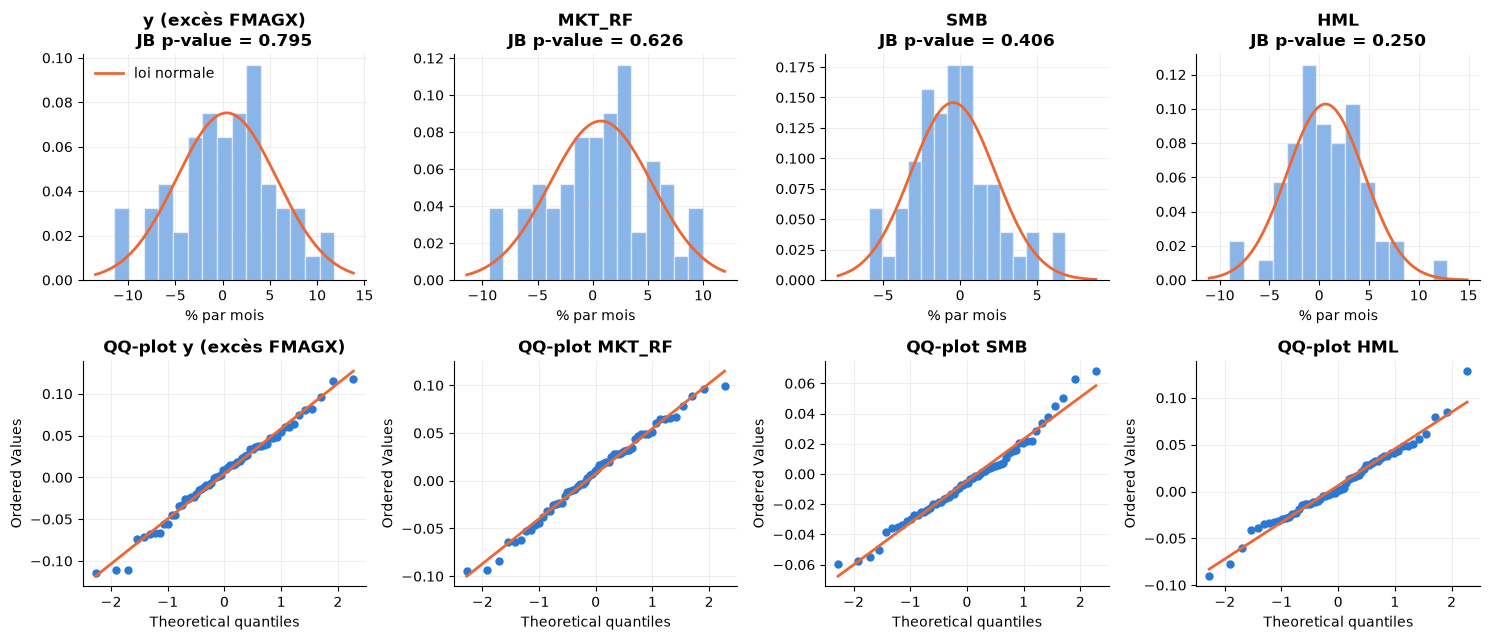

In [12]:
series_plot = {"y (excès FMAGX)": data["y"], "MKT_RF": data["MKT_RF"], "SMB": data["SMB"], "HML": data["HML"]}
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for j, (name, s) in enumerate(series_plot.items()):
    ax = axes[0, j]
    ax.hist(s * 100, bins=15, density=True, color=COLORS["fonds"], alpha=0.55, edgecolor="white")
    x = np.linspace(s.min() * 100 - 2, s.max() * 100 + 2, 200)
    ax.plot(x, stats.norm.pdf(x, s.mean() * 100, s.std() * 100), color=COLORS["marche"], label="loi normale")
    ax.set_title(f"{name}\nJB p-value = {stats.jarque_bera(s).pvalue:.3f}")
    ax.set_xlabel("% par mois")
    if j == 0: ax.legend()
    stats.probplot(s, dist="norm", plot=axes[1, j])
    axes[1, j].get_lines()[0].set(color=COLORS["fonds"], markersize=5)
    axes[1, j].get_lines()[1].set(color=COLORS["marche"])
    axes[1, j].set_title(f"QQ-plot {name}")
plt.tight_layout(); plt.show()

### 5.3 Corrélations
La matrice de corrélation donne un premier aperçu : (i) des liens entre le fonds et chaque facteur (ce que la régression
va mesurer « toutes choses égales par ailleurs ») ; (ii) des liens **entre facteurs**, qui annoncent un éventuel problème
de multicolinéarité (quantifié par le VIF au §7).

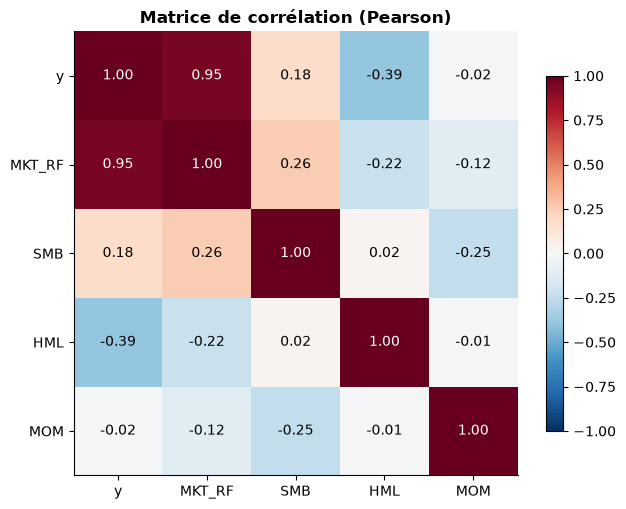

Corrélation de y avec chaque facteur (test de nullité) :
  MKT_RF  r = +0.951   p-value = 0.0000
  SMB     r = +0.181   p-value = 0.1656
  HML     r = -0.388   p-value = 0.0022
  MOM     r = -0.017   p-value = 0.8947


In [13]:
corr = data[["y"] + FACTORS4].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns); ax.set_yticks(range(len(corr)), corr.index)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black", fontsize=10)
fig.colorbar(im, ax=ax, shrink=0.8); ax.set_title("Matrice de corrélation (Pearson)")
plt.tight_layout(); plt.show()

# Significativité des corrélations avec le fonds
print("Corrélation de y avec chaque facteur (test de nullité) :")
for f in FACTORS4:
    r_, p_ = stats.pearsonr(data["y"], data[f])
    print(f"  {f:<7} r = {r_:+.3f}   p-value = {p_:.4f}")

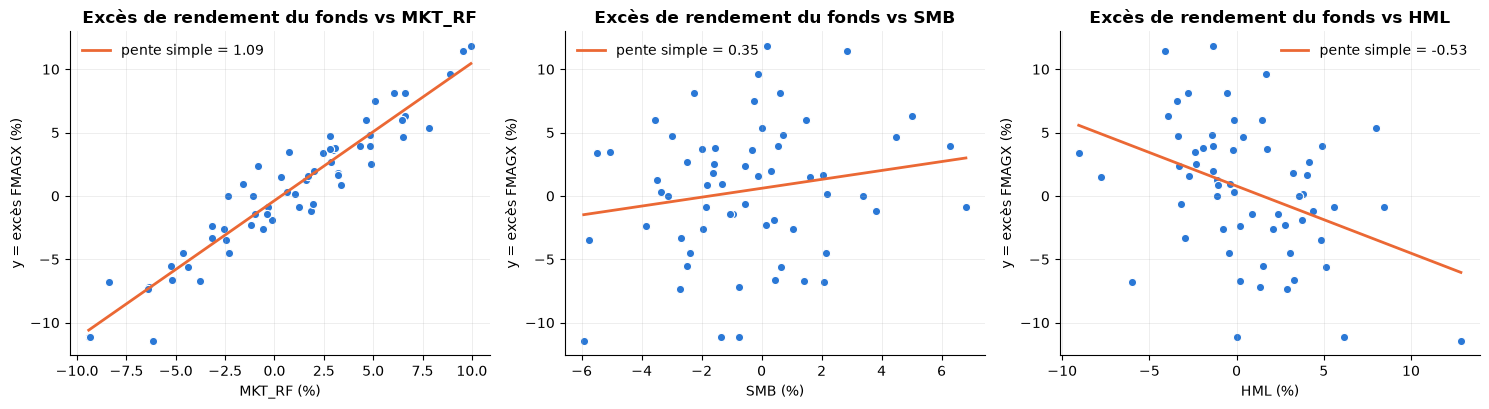

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, f in zip(axes, FACTORS3):
    ax.scatter(data[f] * 100, data["y"] * 100, color=COLORS["fonds"], s=35, edgecolor="white", linewidth=0.8)
    b1, b0 = np.polyfit(data[f], data["y"], 1)
    xs = np.linspace(data[f].min(), data[f].max(), 50)
    ax.plot(xs * 100, (b0 + b1 * xs) * 100, color=COLORS["marche"], label=f"pente simple = {b1:.2f}")
    ax.set_xlabel(f"{f} (%)"); ax.set_ylabel("y = excès FMAGX (%)"); ax.legend()
    ax.set_title(f"Excès de rendement du fonds vs {f}")
plt.tight_layout(); plt.show()

**Lecture des corrélations.**
* **Le fonds est d'abord un fonds « marché »** : corrélation de **0,95** entre $y_t$ et $R_{mt}-R_{ft}$.
* **Corrélation significativement négative avec HML (−0,39, p = 0,002)** : le fonds souffre quand les valeurs
  décotées surperforment. C'est un premier indice d'un **biais *growth***.
* **Corrélation avec SMB positive mais non significative (+0,18)**. Attention, c'est une corrélation *simple* : SMB est
  lui-même corrélé au marché (+0,26), si bien qu'une partie de ce lien passe par le marché. La régression multiple
  mesure l'effet de SMB **à marché constant**, qui peut être de signe opposé (c'est ce qu'on observera au §6). C'est
  l'illustration concrète de la différence entre corrélation simple et effet partiel *ceteris paribus* (chapitre 3).
* **Les facteurs sont faiblement corrélés entre eux** (|ρ| ≤ 0,26). C'est voulu par leur construction (portefeuilles
  long–short) et cela annonce **l'absence de multicolinéarité** (confirmée par le VIF au §7.1).

## 6. Modélisation : estimation MCO du modèle de Fama–French à 3 facteurs

On estime le modèle par **moindres carrés ordinaires** avec `statsmodels.api.OLS`. Point de vigilance du cours :
`sm.OLS` n'ajoute **pas** de constante par défaut ; il faut appeler `sm.add_constant(X)`. Sans cela, on forcerait
$\alpha_i = 0$, c'est-à-dire qu'on **supposerait** la réponse à la question posée.

Pour mieux lire l'apport des facteurs de style, on estime aussi le **CAPM** (un seul facteur, le marché) : comparer
les deux alphas montre ce que « devient » la performance une fois les biais de style pris en compte.

In [15]:
y = data["y"]
X3 = sm.add_constant(data[FACTORS3])
ff3 = sm.OLS(y, X3).fit()
print(ff3.summary(title=f"Fama-French 3 facteurs - {TICKER} - {first_p} à {last_p}"))

              Fama-French 3 facteurs - FMAGX - 2021-08 à 2026-07              
Dep. Variable:                      y   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     282.8
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           8.74e-34
Time:                        11:39:53   Log-Likelihood:                 175.03
No. Observations:                  60   AIC:                            -342.1
Df Residuals:                      56   BIC:                            -333.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0023      0.002     -1.253      0.2

In [16]:
capm = sm.OLS(y, sm.add_constant(data[["MKT_RF"]])).fit()

def coef_table(res, name):
    ci = res.conf_int(alpha=SEUIL)
    return pd.DataFrame({"modèle": name, "coef": res.params, "écart-type": res.bse, "t": res.tvalues,
                         "p-value": res.pvalues, "IC 95% bas": ci[0], "IC 95% haut": ci[1],
                         "signif. 5%": np.where(res.pvalues < SEUIL, "oui", "non")})

print(f"CAPM : R² = {capm.rsquared:.3f} | R² ajusté = {capm.rsquared_adj:.3f}")
print(f"FF3  : R² = {ff3.rsquared:.3f} | R² ajusté = {ff3.rsquared_adj:.3f}\n")
pd.concat([coef_table(capm, "CAPM"), coef_table(ff3, "FF3")])

CAPM : R² = 0.904 | R² ajusté = 0.902
FF3  : R² = 0.938 | R² ajusté = 0.935



,modèle,coef,écart-type,t,p-value,IC 95% bas,IC 95% haut,signif. 5%
const,CAPM,-0.0037,0.0022,-1.6860,0.0972,-0.0080,0.0007,non
MKT_RF,CAPM,1.0866,0.0466,23.3103,0.0000,0.9933,1.1799,oui
const,FF3,-0.0023,0.0019,-1.2527,0.2155,-0.0060,0.0014,non
MKT_RF,FF3,1.0554,0.0405,26.0611,0.0000,0.9742,1.1365,oui
SMB,FF3,-0.0983,0.0669,-1.4685,0.1476,-0.2323,0.0358,non
HML,FF3,-0.2453,0.0468,-5.2418,0.0000,-0.3390,-0.1515,oui


### 6.1 Tests complémentaires

* **Alpha annualisé** : $\alpha_{an} \approx 12\,\hat\alpha$ (lecture plus parlante pour un investisseur).
* **Le fonds est-il plus risqué que le marché ?** Test $H_0 : \beta_{i1} = 1$ (la statistique par défaut de statsmodels
  teste $\beta = 0$, ce qui est sans intérêt pour le bêta de marché d'un fonds actions).
* **Les facteurs de style apportent-ils quelque chose au CAPM ?** Test de Fisher joint $H_0 : \beta_{i2} = \beta_{i3} = 0$.

In [17]:
a, p_a = ff3.params["const"], ff3.pvalues["const"]
print(f"Alpha mensuel = {a:+.4%}  -> alpha annualisé ≈ {12 * a:+.2%}   (p-value = {p_a:.4f})")
print(f"IC 95 % de l'alpha annualisé : [{12 * ff3.conf_int().loc['const', 0]:+.2%} ; {12 * ff3.conf_int().loc['const', 1]:+.2%}]")
print("Conclusion :", "alpha SIGNIFICATIF au seuil de 5 %" if p_a < SEUIL else "alpha NON significatif au seuil de 5 % (H0 : alpha = 0 non rejetée)")

t_beta1 = ff3.t_test("MKT_RF = 1")
print(f"\nTest H0 : beta_marché = 1 -> t = {float(np.squeeze(t_beta1.tvalue)):.3f}, p-value = {float(t_beta1.pvalue):.4f}")

te = np.sqrt(ff3.scale)
print(f"\nÉcart-type résiduel (risque spécifique / tracking error vs portefeuille factoriel) : "
      f"{te:.2%}/mois, soit {te * np.sqrt(12):.2%}/an")
print(f"Part du risque total expliquée par les facteurs (R²) : {ff3.rsquared:.1%}")

f_style = ff3.f_test("SMB = 0, HML = 0")
print(f"Test de Fisher H0 : beta_SMB = beta_HML = 0 -> F = {float(np.squeeze(f_style.fvalue)):.3f}, p-value = {float(f_style.pvalue):.2e}")
f_nested = ff3.compare_f_test(capm)
print(f"(équivalent : comparaison emboîtée FF3 vs CAPM -> F = {f_nested[0]:.3f}, p-value = {f_nested[1]:.2e})")

Alpha mensuel = -0.2323%  -> alpha annualisé ≈ -2.79%   (p-value = 0.2155)
IC 95 % de l'alpha annualisé : [-7.25% ; +1.67%]
Conclusion : alpha NON significatif au seuil de 5 % (H0 : alpha = 0 non rejetée)

Test H0 : beta_marché = 1 -> t = 1.367, p-value = 0.1771

Écart-type résiduel (risque spécifique / tracking error vs portefeuille factoriel) : 1.35%/mois, soit 4.69%/an
Part du risque total expliquée par les facteurs (R²) : 93.8%
Test de Fisher H0 : beta_SMB = beta_HML = 0 -> F = 15.606, p-value = 4.10e-06
(équivalent : comparaison emboîtée FF3 vs CAPM -> F = 15.606, p-value = 4.10e-06)


In [18]:
# Décomposition de la performance moyenne : d'où vient le rendement excédentaire moyen du fonds ?
contrib = ff3.params[FACTORS3] * data[FACTORS3].mean()
decomp = pd.Series({"alpha": ff3.params["const"], **{f"{f} (beta x prime moyenne)": contrib[f] for f in FACTORS3}})
decomp["= excès de rendement moyen du fonds"] = decomp.sum()
(decomp * 12 * 100).round(2).to_frame("contribution annualisée (points de %)")

,contribution annualisée (points de %)
alpha,-2.7900
MKT_RF (beta x prime moyenne),9.4200
SMB (beta x prime moyenne),0.5400
HML (beta x prime moyenne),-1.8700
= excès de rendement moyen du fonds,5.3000


### 6.2 Analyse de style et de risque

**Qualité globale.** Le R² vaut **0,938** (R² ajusté 0,935) : **près de 94 % de la variance** des rendements
excédentaires du fonds sont expliqués par les trois facteurs. Le test de Fisher global (F = 283, p ≈ 10⁻³⁴) rejette
massivement la nullité jointe des bêtas. Le risque spécifique restant (écart-type résiduel) est d'environ
**1,35 %/mois, soit 4,7 %/an** : c'est la seule partie du risque du fonds qui reflète des choix propres au gérant.

**Alpha de Jensen : pas de talent démontré.**
* $\hat\alpha_i$ = **−0,23 % par mois, soit environ −2,8 % par an**, avec $t = -1{,}25$ et une **p-value de 0,216 > 0,05**.
  On **ne rejette pas** $H_0 : \alpha_i = 0$ : **aucune preuve statistique d'un talent de sélection**.
* L'estimation ponctuelle est même **négative** : une fois ses expositions factorielles prises en compte, le fonds a fait
  *moins bien* que le portefeuille de facteurs équivalent. Ce résultat est cohérent avec les frais de gestion et avec la
  littérature (Jensen, 1968 ; Carhart, 1997), où la majorité des fonds actifs ne battent pas les facteurs **nets de frais**.
* L'intervalle de confiance à 95 % de l'alpha annualisé, **[−7,3 % ; +1,7 %]**, est très large : 5 ans de données ne
  permettent ni d'exclure un petit talent, ni d'exclure une destruction de valeur importante (voir le bilan critique).
* **Comparaison avec le CAPM.** L'alpha du CAPM est plus négatif (−0,37 %/mois, p = 0,097). Une partie de la
  sous-performance apparente du fonds face au marché **s'explique par son style *growth***, pénalisé sur une période où
  le facteur *value* a rapporté +7,6 %/an. Ce n'est pas un défaut de sélection de titres, mais un choix de style.

**Bêtas : analyse de style et de risque.**
* $\hat\beta_{i1}$ = **1,055** (très significatif) : le fonds amplifie légèrement les mouvements du marché. Une hausse
  de 1 % de l'excès de rendement du marché se traduit en moyenne par +1,06 % pour le fonds. Le test $H_0 : \beta_{i1} = 1$
  n'est **pas rejeté** (p = 0,18) : statistiquement, le fonds a le **risque systématique du marché**. Il n'est ni
  défensif ni significativement agressif.
* $\hat\beta_{i2}$ = **−0,098**, **non significatif** (p = 0,148). Le signe négatif va dans le sens d'un biais
  **grandes capitalisations**, cohérent avec l'étiquette « large cap » du fonds, mais on ne peut pas l'affirmer au seuil de
  5 % sur 60 mois. Ce coefficient est fragile : il devient significatif sans les mois influents (§7.4) et sur les 48
  premiers mois (§8).
* $\hat\beta_{i3}$ = **−0,245**, **très significatif** (t = −5,2) : **biais *growth* marqué**. Quand les valeurs
  décotées surperforment les valeurs de croissance de 1 %, le fonds perd environ 0,25 % par rapport à ce que prédit le
  marché seul. FMAGX est donc un fonds **« large cap growth »** plus qu'un fonds « large cap diversifié ».
* Le test joint $\beta_{i2} = \beta_{i3} = 0$ est **fortement rejeté** (F = 15,6, p ≈ 4·10⁻⁶), et le R² ajusté passe
  de 0,902 (CAPM) à 0,935 (FF3). **Les facteurs de style sont nécessaires** pour décrire ce fonds.

**Décomposition de la performance** (tableau ci-dessus). L'excès de rendement moyen du fonds (**+5,3 %/an**) se
décompose en environ **+9,4 %/an de prime de marché** ($\hat\beta_{i1} \times$ prime moyenne), **+0,5 %/an** de prime de
taille, **−1,9 %/an de coût du biais *growth*** et **−2,8 %/an d'alpha**. Autrement dit, **toute la performance du fonds
vient de son exposition au marché**. Le biais de style et la sélection de titres ont, en net, retranché du rendement.

## 7. Validation et diagnostic du modèle

Les p-values du §6 ne sont valides que si les hypothèses des MCO sont (approximativement) respectées. On vérifie
systématiquement :

| Hypothèse / problème | Outil | Conséquence si violé |
|---|---|---|
| Absence de multicolinéarité forte | **VIF** | écarts-types gonflés, coefficients instables |
| Homoscédasticité des erreurs | **Breusch–Pagan** (+ White) | écarts-types MCO biaisés ⇒ correction de **White (HC1)** |
| Normalité des résidus | **Jarque–Bera** + QQ-plot | tests $t$ et $F$ seulement asymptotiquement valides |
| Absence d'autocorrélation des erreurs | **Durbin–Watson**, **Ljung–Box** | écarts-types biaisés (⇒ Newey–West) |
| Absence de points trop influents | **distance de Cook** | estimation « pilotée » par quelques mois |

### 7.1 Multicolinéarité : VIF

$$ VIF_j = \frac{1}{1 - R_j^2} $$
où $R_j^2$ est le R² de la régression du facteur $j$ sur les autres facteurs. Règle usuelle : $VIF > 5$ signale une
colinéarité préoccupante, $VIF > 10$ une colinéarité sévère. Le VIF se calcule sur la matrice **avec constante** (sinon
les VIF sont faussés) mais on n'interprète pas celui de la constante.

In [19]:
def vif_table(X):
    return pd.Series([variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])],
                     index=X.columns[1:], name="VIF").to_frame().assign(**{"R²_j": lambda d: 1 - 1 / d["VIF"]})

vif3 = vif_table(X3)
vif3

,VIF,R²_j
MKT_RF,1.1349,0.1188
SMB,1.0784,0.0727
HML,1.0611,0.0576


**Aucune multicolinéarité.** Les VIF sont compris entre **1,06 et 1,13**, très loin du seuil de 5 : chaque facteur
n'est expliqué qu'à 6–12 % par les deux autres ($R_j^2$). Les écarts-types des bêtas ne sont donc pas gonflés, et les
effets du marché, de la taille et du style sont estimés **séparément et précisément**. C'est la propriété attendue de
facteurs construits comme des portefeuilles long–short quasi orthogonaux. Ce ne serait pas forcément le cas dans la
variante obligataire (TERM, DEF et le marché sont liés en période de stress).

### 7.2 Hétéroscédasticité : test de Breusch–Pagan, puis correction de White (HC1)

Le test de Breusch–Pagan régresse les résidus au carré $\hat\varepsilon_t^2$ sur les régresseurs :
$H_0$ : la variance des erreurs est constante (homoscédasticité). La statistique $LM = n R^2_{aux} \sim \chi^2(k)$.
On complète par le **test de White**, qui ajoute les carrés et produits croisés des régresseurs et détecte donc des
formes plus générales d'hétéroscédasticité.

**Protocole de l'énoncé :** en cas de rejet de $H_0$, on ré-estime avec les écarts-types robustes de White
(`cov_type="HC1"`). Les coefficients $\hat\beta$ ne changent **pas** (ils restent sans biais sous hétéroscédasticité) :
seuls les **écarts-types, t et p-values** changent. Par souci de transparence, nous présentons la comparaison
MCO / HC1 **quel que soit** le résultat du test.

In [20]:
bp_lm, bp_p, bp_f, bp_fp = smd.het_breuschpagan(ff3.resid, X3)
w_lm, w_p, w_f, w_fp = smd.het_white(ff3.resid, X3)
print(f"Breusch-Pagan : LM = {bp_lm:.3f}, p-value = {bp_p:.4f}  (version F : {bp_f:.3f}, p = {bp_fp:.4f})")
print(f"White         : LM = {w_lm:.3f}, p-value = {w_p:.4f}")
homo_rejetee = bp_p < SEUIL
print("\n=> Homoscédasticité", "REJETÉE : correction HC1 nécessaire." if homo_rejetee else
      "NON rejetée au seuil de 5 % : les écarts-types MCO classiques sont valides ;\n   la version HC1 est présentée comme contrôle de robustesse.")

ff3_hc1 = sm.OLS(y, X3).fit(cov_type="HC1")
cmp_hc = pd.DataFrame({
    "coef": ff3.params,
    "é-t MCO": ff3.bse, "é-t HC1": ff3_hc1.bse, "ratio HC1/MCO": ff3_hc1.bse / ff3.bse,
    "p MCO": ff3.pvalues, "p HC1": ff3_hc1.pvalues,
    "signif. MCO": np.where(ff3.pvalues < SEUIL, "oui", "non"),
    "signif. HC1": np.where(ff3_hc1.pvalues < SEUIL, "oui", "non"),
})
cmp_hc

Breusch-Pagan : LM = 2.112, p-value = 0.5495  (version F : 0.681, p = 0.5674)
White         : LM = 5.558, p-value = 0.7832

=> Homoscédasticité NON rejetée au seuil de 5 % : les écarts-types MCO classiques sont valides ;
   la version HC1 est présentée comme contrôle de robustesse.


,coef,é-t MCO,é-t HC1,ratio HC1/MCO,p MCO,p HC1,signif. MCO,signif. HC1
const,-0.0023,0.0019,0.0018,0.9869,0.2155,0.2043,non,non
MKT_RF,1.0554,0.0405,0.0336,0.8301,0.0000,0.0000,oui,oui
SMB,-0.0983,0.0669,0.0659,0.9852,0.1476,0.1361,non,non
HML,-0.2453,0.0468,0.0506,1.0815,0.0000,0.0000,oui,oui


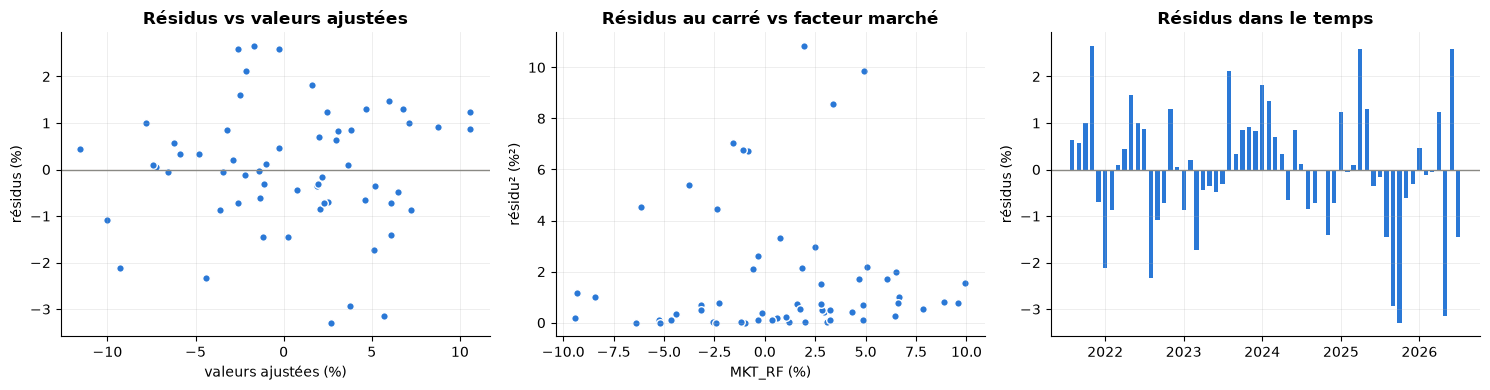

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(ff3.fittedvalues * 100, ff3.resid * 100, color=COLORS["fonds"], s=30, edgecolor="white")
axes[0].axhline(0, color=COLORS["gris"], lw=1)
axes[0].set(xlabel="valeurs ajustées (%)", ylabel="résidus (%)", title="Résidus vs valeurs ajustées")
axes[1].scatter(data["MKT_RF"] * 100, ff3.resid ** 2 * 1e4, color=COLORS["fonds"], s=30, edgecolor="white")
axes[1].set(xlabel="MKT_RF (%)", ylabel="résidu² (%²)", title="Résidus au carré vs facteur marché")
axes[2].bar(data.index.to_timestamp(), ff3.resid * 100, width=20, color=COLORS["fonds"])
axes[2].axhline(0, color=COLORS["gris"], lw=1)
axes[2].set(ylabel="résidus (%)", title="Résidus dans le temps")
plt.tight_layout(); plt.show()

**Homoscédasticité non rejetée.** Breusch–Pagan : LM = 2,11, **p = 0,55**. White : p = 0,78. On ne rejette pas l'hypothèse
de variance constante des erreurs. Les graphiques le confirment : pas de forme en « entonnoir » des résidus en fonction
des valeurs ajustées ou du marché. Les résidus au carré les plus élevés apparaissent pour des mois de marché *moyen*,
pas extrêmes.

**Impact concret de la correction de White (HC1).** Le protocole de l'énoncé ne l'impose pas ici, mais nous l'avons
appliquée par transparence :
* les **coefficients sont strictement identiques** (seule la matrice de variance change) ;
* les écarts-types bougent peu : −1 % pour l'alpha, −1,5 % pour SMB, +8 % pour HML, et **−17 % pour le bêta de marché** ;
* la **p-value de l'alpha passe de 0,216 à 0,204**, celle de SMB de 0,148 à 0,136, et HML et le marché restent
  significatifs à moins de 10⁻⁵ ;
* **aucune conclusion ne change au seuil de 5 %.**

C'est le résultat attendu quand Breusch–Pagan ne rejette pas : MCO et HC1 convergent. Si le test avait rejeté
l'homoscédasticité (typiquement sur une période incluant un krach comme 2008 ou mars 2020), les écarts-types MCO
auraient pu être nettement sous-estimés, et un alpha « significatif » aurait pu devenir non significatif une fois corrigé.
Comme Breusch–Pagan a une **puissance limitée avec 60 observations**, présenter systématiquement les p-values HC1 à côté
des p-values MCO reste une bonne pratique d'audit, peu coûteuse.

### 7.3 Normalité et autocorrélation des résidus

Jarque-Bera sur les résidus : JB = 1.082, p-value = 0.5820 -> normalité non rejetée
Skewness résidus = -0.314 | kurtosis = 3.195

Durbin-Watson = 1.587  (2 = pas d'autocorrélation d'ordre 1 ; < 2 : autocorrélation positive)
Ljung-Box (H0 : pas d'autocorrélation jusqu'au retard h) :


,lb_stat,lb_pvalue
1,2.3784,0.1230
3,3.9292,0.2692
6,8.3935,0.2107
12,10.0236,0.6139


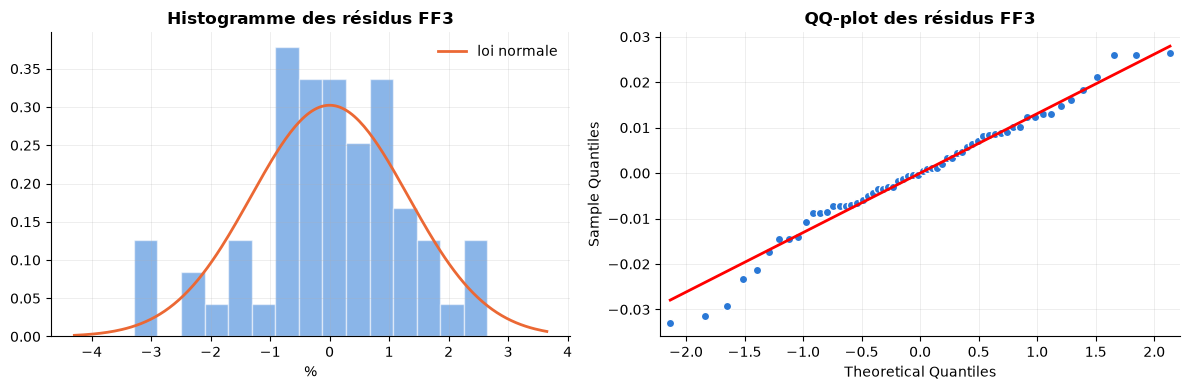

,p MCO,p HC1,p Newey-West (3 retards)
const,0.2155,0.2043,0.2594
MKT_RF,0.0000,0.0000,0.0000
SMB,0.1476,0.1361,0.1068
HML,0.0000,0.0000,0.0000


In [22]:
jb_res = stats.jarque_bera(ff3.resid)
print(f"Jarque-Bera sur les résidus : JB = {jb_res.statistic:.3f}, p-value = {jb_res.pvalue:.4f} "
      f"-> normalité {'rejetée' if jb_res.pvalue < SEUIL else 'non rejetée'}")
print(f"Skewness résidus = {stats.skew(ff3.resid):+.3f} | kurtosis = {stats.kurtosis(ff3.resid, fisher=False):.3f}")
dw = durbin_watson(ff3.resid)
print(f"\nDurbin-Watson = {dw:.3f}  (2 = pas d'autocorrélation d'ordre 1 ; < 2 : autocorrélation positive)")
lb = smd.acorr_ljungbox(ff3.resid, lags=[1, 3, 6, 12])
print("Ljung-Box (H0 : pas d'autocorrélation jusqu'au retard h) :"); display(lb)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ff3.resid * 100, bins=15, density=True, color=COLORS["fonds"], alpha=0.55, edgecolor="white")
xs = np.linspace(ff3.resid.min() * 100 - 1, ff3.resid.max() * 100 + 1, 200)
axes[0].plot(xs, stats.norm.pdf(xs, 0, ff3.resid.std() * 100), color=COLORS["marche"], label="loi normale")
axes[0].set(title="Histogramme des résidus FF3", xlabel="%"); axes[0].legend()
sm.qqplot(ff3.resid, line="s", ax=axes[1], markerfacecolor=COLORS["fonds"], markeredgecolor="white")
axes[1].set_title("QQ-plot des résidus FF3")
plt.tight_layout(); plt.show()

# Contrôle : écarts-types de Newey-West (HAC), robustes à l'hétéroscédasticité ET à l'autocorrélation
ff3_hac = sm.OLS(y, X3).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
pd.DataFrame({"p MCO": ff3.pvalues, "p HC1": ff3_hc1.pvalues, "p Newey-West (3 retards)": ff3_hac.pvalues})

**Normalité des résidus : non rejetée.** Jarque–Bera = 1,08, **p = 0,58**, avec une skewness de −0,31 et une kurtosis de 3,2,
proches de la loi normale. Le QQ-plot est aligné. Les tests $t$ et $F$ du §6 sont donc valides même en petit
échantillon.

**Autocorrélation : pas de problème significatif.** Durbin–Watson = **1,59**. Pour $n = 60$ et $k = 3$, les bornes
tabulées au seuil de 5 % sont environ $d_L \approx 1{,}48$ et $d_U \approx 1{,}69$ : on est dans la **zone
d'indétermination**. Le test de Ljung–Box tranche : **aucune autocorrélation significative** aux retards 1, 3, 6 et 12
(toutes les p-values > 0,12). Par précaution, les écarts-types de **Newey–West** (robustes à l'hétéroscédasticité *et*
à l'autocorrélation) donnent une p-value de l'alpha de 0,26, et **la conclusion est inchangée**.

> 🔗 **Transition vers le Projet 2** : des résidus proches d'un bruit blanc laissent peu de structure à exploiter
> pour un modèle ARMA. Il faudra évaluer honnêtement si un ARMA apporte un gain de prévision par rapport à une
> prévision naïve.

### 7.4 Points influents : distance de Cook

La distance de Cook mesure de combien **l'ensemble des coefficients** bouge quand on retire l'observation $t$ :
$$ D_t = \frac{\hat\varepsilon_t^2}{k\, s^2}\,\frac{h_{tt}}{(1-h_{tt})^2} $$
Elle combine un gros **résidu** et un fort **effet de levier** $h_{tt}$ (un mois où les facteurs prennent des valeurs
extrêmes). Seuil indicatif : $D_t > 4/n$. Un point influent n'est pas à supprimer automatiquement : on vérifie **si les
conclusions changent** quand on l'exclut.

Seuil 4/n = 0.0667 -> 3 mois influent(s)


,Cook,levier h,résidu studentisé,y,MKT_RF,SMB,HML
2022-01,0.2899,0.2589,-1.8616,-0.1143,-0.0616,-0.0593,0.1286
2023-03,0.1060,0.1769,-1.4167,0.0342,0.0248,-0.0548,-0.0905
2026-06,0.0693,0.0656,2.0413,0.0003,-0.0107,0.0339,0.0358


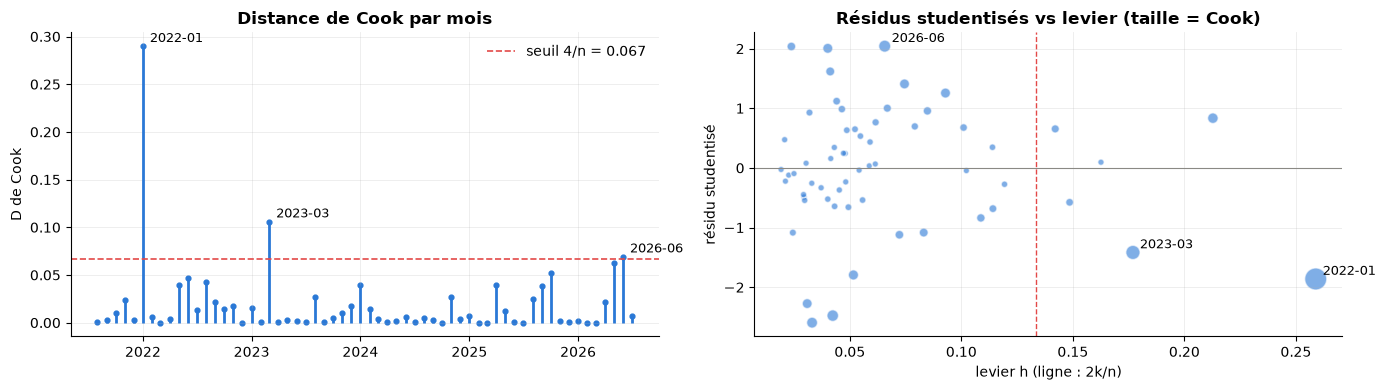

In [23]:
infl = ff3.get_influence()
cooks = pd.Series(infl.cooks_distance[0], index=data.index, name="Cook")
lev = pd.Series(infl.hat_matrix_diag, index=data.index, name="levier h")
stud = pd.Series(infl.resid_studentized_external, index=data.index, name="résidu studentisé")
n = len(y); seuil_cook = 4 / n
influents = cooks[cooks > seuil_cook].sort_values(ascending=False)
print(f"Seuil 4/n = {seuil_cook:.4f} -> {len(influents)} mois influent(s)")
tab_infl = pd.concat([cooks, lev, stud, data[["y"] + FACTORS3]], axis=1).loc[influents.index]
display(tab_infl)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
t = data.index.to_timestamp()
axes[0].vlines(t, 0, cooks, color=COLORS["fonds"], lw=2)
axes[0].scatter(t, cooks, color=COLORS["fonds"], s=12)
axes[0].axhline(seuil_cook, color=COLORS["rouge"], ls="--", lw=1.2, label=f"seuil 4/n = {seuil_cook:.3f}")
for p in influents.index:
    axes[0].annotate(str(p), (p.to_timestamp(), cooks[p]), textcoords="offset points", xytext=(5, 3), fontsize=9)
axes[0].set(title="Distance de Cook par mois", ylabel="D de Cook"); axes[0].legend()
axes[1].scatter(lev, stud, s=20 + 800 * cooks, color=COLORS["fonds"], alpha=0.6, edgecolor="white")
axes[1].axhline(0, color=COLORS["gris"], lw=0.8); axes[1].axvline(2 * X3.shape[1] / n, color=COLORS["rouge"], ls="--", lw=1)
for p in influents.index:
    axes[1].annotate(str(p), (lev[p], stud[p]), textcoords="offset points", xytext=(5, 3), fontsize=9)
axes[1].set(title="Résidus studentisés vs levier (taille = Cook)", xlabel="levier h (ligne : 2k/n)", ylabel="résidu studentisé")
plt.tight_layout(); plt.show()

In [24]:
# Robustesse : ré-estimation sans les mois influents
mask = ~data.index.isin(influents.index)
ff3_sans = sm.OLS(y[mask], X3[mask]).fit()
robust_cook = pd.DataFrame({
    "coef (60 mois)": ff3.params, "p (60 mois)": ff3.pvalues,
    f"coef (sans {len(influents)} mois)": ff3_sans.params, f"p (sans {len(influents)} mois)": ff3_sans.pvalues,
})
print(f"R² ajusté : {ff3.rsquared_adj:.3f} (complet) -> {ff3_sans.rsquared_adj:.3f} (sans points influents)")
robust_cook

R² ajusté : 0.935 (complet) -> 0.940 (sans points influents)


,coef (60 mois),p (60 mois),coef (sans 3 mois),p (sans 3 mois)
const,-0.0023,0.2155,-0.0025,0.1667
MKT_RF,1.0554,0.0000,1.0622,0.0000
SMB,-0.0983,0.1476,-0.1838,0.0097
HML,-0.2453,0.0000,-0.2381,0.0000


**Trois mois dépassent le seuil 4/n ≈ 0,067.** Aucun ne dépasse le seuil « fort » $D_t > 1$ : aucune observation ne
dicte à elle seule la régression.
* **Janvier 2022** (D = 0,29, de loin le plus influent) : levier élevé (h = 0,26) car HML (+12,9 %), SMB (−5,9 %) et le
  marché (−6,2 %) prennent simultanément des valeurs extrêmes. C'est la rotation *growth → value* au début du resserrement
  monétaire. Le fonds perd 11,4 %, **encore plus** que ne le prédisent ses bêtas.
* **Mars 2023** (D = 0,11) : crise SVB, HML à −9,1 % (levier 0,18).
* **Juin 2026** (D = 0,07) : c'est surtout un gros résidu positif (résidu studentisé +2,0), avec peu de levier.

**Ré-estimation sans ces 3 mois :**
* alpha : −0,25 %/mois, p = 0,17. **La conclusion principale (pas d'alpha significatif) est robuste** ;
* bêta de marché (1,06) et bêta HML (−0,24) quasiment inchangés. **Le biais *growth* est robuste** ;
* **le bêta SMB double (−0,10 → −0,18) et devient significatif (p = 0,01)**. L'exposition « grandes capitalisations »
  est donc réelle mais **masquée par deux mois atypiques** (janvier 2022 et mars 2023, où SMB était très négatif).

**Décision.** Nous **conservons ces mois** dans le modèle principal : ce sont des événements de marché réels, sans erreur
de données, et les exclure reviendrait à choisir l'échantillon en fonction du résultat. Nous **signalons** en revanche que
la conclusion sur le facteur taille dépend de ces deux mois.

## 8. Interprétation sur un échantillon jamais utilisé pour l'estimation

L'étape 8 de la méthodologie demande de confronter le modèle à des données **non utilisées pour l'estimation**. Pour
un modèle d'attribution de performance comme Fama–French, la question pertinente n'est pas de « prévoir » le rendement
du fonds (il faudrait pour cela prévoir les facteurs eux-mêmes, ce qui relève du Projet 2), mais de vérifier que :

1. **les bêtas estimés sont stables** : estimés sur les 48 premiers mois, expliquent-ils encore les rendements des 12
   derniers mois, une fois les facteurs réalisés connus ? ;
2. **l'alpha persiste** : le gérant fait-il mieux ou moins bien que son « portefeuille de facteurs » répliquant
   sur une période qu'il n'a pas servi à calibrer ?

**Protocole.** Échantillon d'estimation : 48 premiers mois. Échantillon de test : 12 derniers mois.
Pour chaque mois de test, rendement expliqué $\hat y_t = \hat\alpha + \hat\beta' f_t$ (facteurs $f_t$ réalisés).
Comparaison à deux références : la **moyenne historique** (modèle naïf, sans facteurs) et le **CAPM**.
Métriques : RMSE, MAE et $R^2_{hors\,éch.} = 1 - \sum (y_t-\hat y_t)^2 / \sum (y_t-\bar y_{estim})^2$.

In [25]:
train, test = data.index[:-N_TEST], data.index[-N_TEST:]
print(f"Estimation : {train[0]} -> {train[-1]} ({len(train)} mois) | Test : {test[0]} -> {test[-1]} ({len(test)} mois)")

specs = {"CAPM": ["MKT_RF"], "FF3": FACTORS3, "Carhart (FF3+MOM)": FACTORS4}
fits_train = {k: sm.OLS(y[train], sm.add_constant(data.loc[train, v])).fit() for k, v in specs.items()}

preds = pd.DataFrame({"réalisé": y[test], "Naïf (moyenne)": y[train].mean()}, index=test)
for k, v in specs.items():
    preds[k] = fits_train[k].predict(sm.add_constant(data.loc[test, v], has_constant="add"))

def oos_metrics(real, pred, bench):
    e = real - pred
    return pd.Series({"RMSE": np.sqrt((e ** 2).mean()), "MAE": e.abs().mean(),
                      "R² hors éch.": 1 - (e ** 2).sum() / ((real - bench) ** 2).sum()})

oos = pd.DataFrame({k: oos_metrics(preds["réalisé"], preds[k], y[train].mean())
                    for k in ["Naïf (moyenne)"] + list(specs)}).T
oos["R² intra-éch. (48 mois)"] = [np.nan] + [fits_train[k].rsquared for k in specs]
oos

Estimation : 2021-08 -> 2025-07 (48 mois) | Test : 2025-08 -> 2026-07 (12 mois)


,RMSE,MAE,R² hors éch.,R² intra-éch. (48 mois)
Naïf (moyenne),0.0424,0.0293,0.0000,NaN
CAPM,0.0191,0.0172,0.7968,0.9166
FF3,0.0203,0.0156,0.7709,0.9605
Carhart (FF3+MOM),0.0195,0.0131,0.7877,0.9643


,FF3 - 48 premiers mois,p (48 mois),FF3 - 60 mois,p (60 mois)
const,-0.0008,0.6572,-0.0023,0.2155
MKT_RF,1.0757,0.0000,1.0554,0.0000
SMB,-0.1454,0.0202,-0.0983,0.1476
HML,-0.2689,0.0000,-0.2453,0.0000


Alpha estimé sur 48 mois : -0.077%/mois (p = 0.657)
Alpha réalisé hors échantillon (12 mois) : -0.961%/mois, soit -11.53%/an (t = -1.74, p = 0.109)


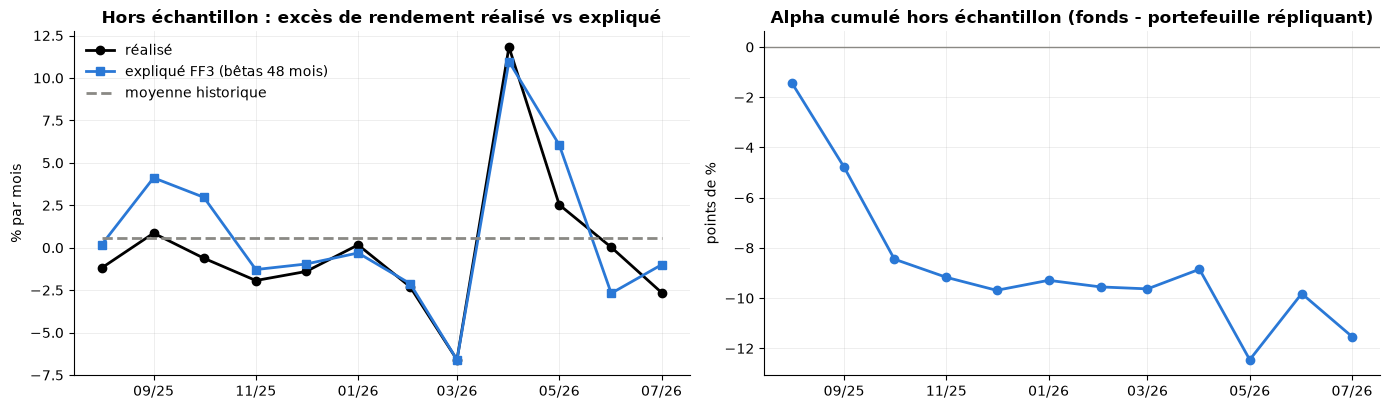

In [26]:
# Stabilité des coefficients : estimation sur 48 mois vs 60 mois
stab = pd.DataFrame({"FF3 - 48 premiers mois": fits_train["FF3"].params, "p (48 mois)": fits_train["FF3"].pvalues,
                     "FF3 - 60 mois": ff3.params, "p (60 mois)": ff3.pvalues})
display(stab)

# Alpha réalisé hors échantillon = rendement du fonds - rendement du portefeuille de facteurs répliquant (sans alpha)
b = fits_train["FF3"].params
replic = (data.loc[test, FACTORS3] * b[FACTORS3]).sum(axis=1)
alpha_oos = y[test] - replic
t_oos = stats.ttest_1samp(alpha_oos, 0)
print(f"Alpha estimé sur 48 mois : {b['const']:+.3%}/mois (p = {fits_train['FF3'].pvalues['const']:.3f})")
print(f"Alpha réalisé hors échantillon (12 mois) : {alpha_oos.mean():+.3%}/mois, soit {alpha_oos.mean()*12:+.2%}/an "
      f"(t = {t_oos.statistic:.2f}, p = {t_oos.pvalue:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
tt = test.to_timestamp()
axes[0].plot(tt, preds["réalisé"] * 100, color="black", marker="o", label="réalisé")
axes[0].plot(tt, preds["FF3"] * 100, color=COLORS["fonds"], marker="s", label="expliqué FF3 (bêtas 48 mois)")
axes[0].plot(tt, preds["Naïf (moyenne)"] * 100, color=COLORS["gris"], ls="--", label="moyenne historique")
axes[0].set(title="Hors échantillon : excès de rendement réalisé vs expliqué", ylabel="% par mois"); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))
axes[1].plot(tt, 100 * np.cumsum(alpha_oos), color=COLORS["fonds"], marker="o")
axes[1].axhline(0, color=COLORS["gris"], lw=1)
axes[1].set(title="Alpha cumulé hors échantillon (fonds - portefeuille répliquant)", ylabel="points de %")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))
plt.tight_layout(); plt.show()

### 8.1 Stabilité du style : régressions glissantes sur 36 mois

Un alpha ou des bêtas estimés sur 5 ans sont des **moyennes** : si le gérant a changé de style (dérive de style), ces
moyennes peuvent masquer des comportements très différents. On ré-estime le modèle sur une fenêtre glissante de 36 mois.

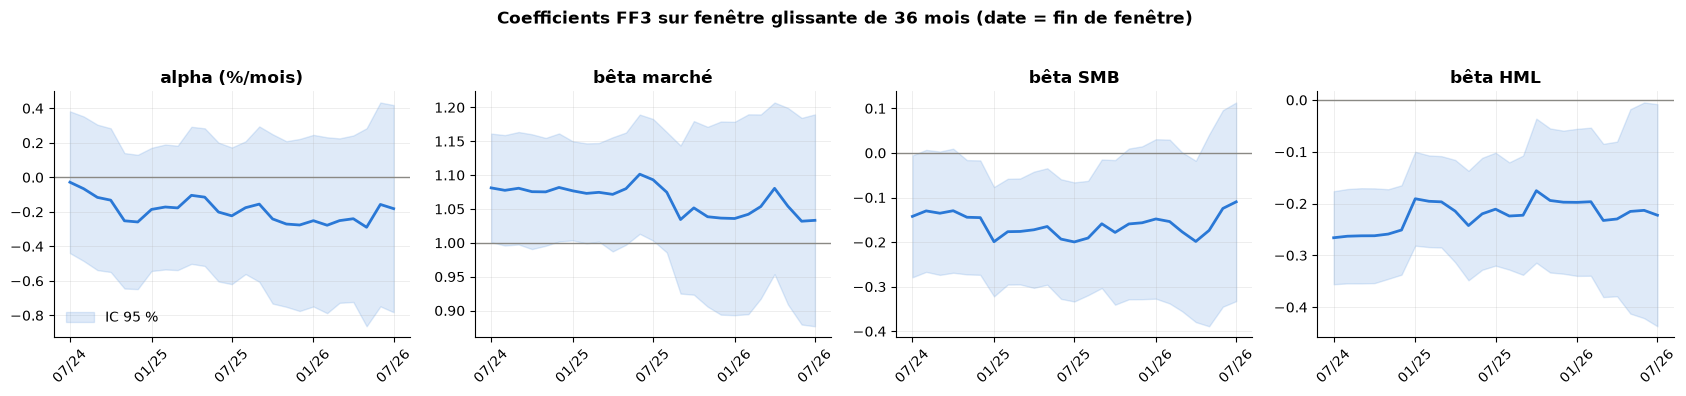

,b_const,b_MKT_RF,b_SMB,b_HML
mean,-0.0019,1.0643,-0.1615,-0.2222
min,-0.0029,1.0319,-0.1996,-0.2660
max,-0.0003,1.1013,-0.1097,-0.1752


In [27]:
WIN = 36
roll = []
for end in range(WIN, len(data) + 1):
    idx = data.index[end - WIN:end]
    r_ = sm.OLS(y[idx], X3.loc[idx]).fit()
    ci = r_.conf_int()
    roll.append(pd.concat([r_.params.add_prefix("b_"), ci[0].add_prefix("lo_"), ci[1].add_prefix("hi_")]).rename(idx[-1]))
roll = pd.DataFrame(roll)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
labels = {"const": "alpha (%/mois)", "MKT_RF": "bêta marché", "SMB": "bêta SMB", "HML": "bêta HML"}
for ax, c in zip(axes, ["const"] + FACTORS3):
    k = 100 if c == "const" else 1
    tr = roll.index.to_timestamp()
    ax.plot(tr, roll[f"b_{c}"] * k, color=COLORS["fonds"])
    ax.fill_between(tr, roll[f"lo_{c}"] * k, roll[f"hi_{c}"] * k, color=COLORS["fonds"], alpha=0.15, label="IC 95 %")
    ax.axhline(1 if c == "MKT_RF" else 0, color=COLORS["gris"], lw=1)
    ax.set_title(labels[c])
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%y"))
    ax.tick_params(axis="x", rotation=45)
axes[0].legend()
fig.suptitle(f"Coefficients FF3 sur fenêtre glissante de {WIN} mois (date = fin de fenêtre)", y=1.03, fontweight="bold")
plt.tight_layout(); plt.show()
roll[[f"b_{c}" for c in ["const"] + FACTORS3]].describe().loc[["mean", "min", "max"]]

**1. Les bêtas sont stables hors échantillon.** Estimés sur les 48 premiers mois (β marché = 1,08, SMB = −0,15, HML = −0,27,
très proches des valeurs sur 60 mois), puis appliqués aux facteurs réalisés des 12 mois suivants, les modèles
factoriels expliquent **environ 77 à 80 % de la variance hors échantillon** ($R^2_{hors\,éch.}$ de 0,77 à 0,80). Ils
divisent l'erreur quadratique par plus de deux par rapport à la moyenne historique (RMSE ≈ 2 % contre 4,2 %/mois).
L'analyse de style est donc **fiable** : ce qu'elle dit du comportement du fonds reste vrai sur des données qu'elle n'a
pas vues.

**2. Les facteurs de style n'améliorent pas l'ajustement hors échantillon par rapport au CAPM.** Le CAPM a un RMSE
légèrement plus faible (1,91 % contre 2,03 % pour FF3), le Carhart a le meilleur MAE. Sur 12 points, ces écarts ne sont pas
significatifs. Mais ils rappellent qu'un meilleur R² *intra*-échantillon (0,96 pour FF3 contre 0,92 pour le CAPM) ne
garantit pas une meilleure performance *hors* échantillon.

**3. Un alpha hors échantillon très négatif.** Sur les 12 derniers mois, le fonds a fait **−0,96 %/mois
(≈ −11,5 %/an) de moins que son portefeuille répliquant**. La sous-performance est concentrée sur **août–octobre 2025**
(≈ −8 points cumulés) et **mai 2026** (≈ −3,5 points). Elle n'est pas significative au seuil de 5 % (t = −1,74, p = 0,11, sur
seulement 12 points), mais elle est économiquement considérable. Elle explique pourquoi l'alpha estimé sur 60 mois
(−2,8 %/an) est bien plus négatif que sur les 48 premiers mois (−0,9 %/an, p = 0,66) : **la dernière année tire l'alpha
vers le bas**, sans jamais faire apparaître de talent positif.

**4. Pas de dérive de style (fenêtres glissantes de 36 mois).** Sur toutes les fenêtres :
* le bêta de marché reste entre **1,03 et 1,10** ;
* le bêta SMB entre **−0,20 et −0,11** ;
* le bêta HML entre **−0,27 et −0,18** ;
* l'alpha est **toujours négatif** (−0,03 à −0,29 %/mois) mais son intervalle de confiance contient toujours 0.

Le gérant a donc un **style constant, « large cap growth » avec un bêta proche de 1**, et ne montre de talent sur aucune
sous-période. Attention : les fenêtres se chevauchent (35 mois communs d'une fenêtre à la suivante), donc les
estimations successives ne sont pas indépendantes.

## 9. Pour aller plus loin : extension à 4 facteurs (Carhart, 1997)

Carhart ajoute le facteur **momentum** (MOM, ou UMD : *Up Minus Down*), qui capte la tendance des actions ayant
fortement monté sur les 12 derniers mois à continuer de surperformer :
$$ R_{it} - R_{ft} = \alpha_i + \beta_{i1}(R_{mt}-R_{ft}) + \beta_{i2}SMB_t + \beta_{i3}HML_t + \beta_{i4}MOM_t + \varepsilon_{it} $$

L'énoncé demande de **justifier** l'ajout du momentum plutôt que de l'ajouter par défaut. Critères utilisés (§3.4) :
* **R² ajusté** : pénalise le nombre de régresseurs, $\bar R^2 = 1 - (1-R^2)\frac{n-1}{n-k-1}$ ;
* **BIC** $= -2\ln L + k\ln n$ : pénalise plus fortement la complexité que l'AIC ($k\ln n$ vs $2k$) ; on retient le
  modèle de **BIC le plus faible** ;
* **test de Fisher emboîté** FF3 vs Carhart (équivalent ici au test $t$ sur $\beta_{i4}$) ;
* **robustesse** : le résultat tient-il avec des écarts-types HC1, sans les points influents, et sur les deux
  sous-périodes ?

In [28]:
X4 = sm.add_constant(data[FACTORS4])
carhart = sm.OLS(y, X4).fit()
print(carhart.summary(title=f"Carhart 4 facteurs - {TICKER}"))

                          Carhart 4 facteurs - FMAGX                          
Dep. Variable:                      y   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     231.7
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           1.02e-33
Time:                        11:39:55   Log-Likelihood:                 178.04
No. Observations:                  60   AIC:                            -346.1
Df Residuals:                      55   BIC:                            -335.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0028      0.002     -1.538      0.1

In [29]:
def crit(res, name):
    return pd.Series({"k (hors constante)": int(res.df_model), "R²": res.rsquared, "R² ajusté": res.rsquared_adj,
                      "AIC": res.aic, "BIC": res.bic, "alpha mensuel": res.params["const"],
                      "p-value alpha": res.pvalues["const"]}, name=name)

comp_models = pd.concat([crit(capm, "CAPM"), crit(ff3, "FF3"), crit(carhart, "Carhart")], axis=1).T
display(comp_models)

f4 = carhart.compare_f_test(ff3)
carhart_hc1 = sm.OLS(y, X4).fit(cov_type="HC1")
print(f"Test F emboîté FF3 -> Carhart : F = {f4[0]:.3f}, p-value = {f4[1]:.4f}")
print(f"beta_MOM = {carhart.params['MOM']:+.3f} | p MCO = {carhart.pvalues['MOM']:.4f} | p HC1 = {carhart_hc1.pvalues['MOM']:.4f}")
print(f"Différence de BIC (Carhart - FF3) = {carhart.bic - ff3.bic:+.2f}  (négatif => Carhart préféré)")
print(f"Breusch-Pagan Carhart : p-value = {smd.het_breuschpagan(carhart.resid, X4)[1]:.4f}")
print("\nVIF du modèle Carhart :"); display(vif_table(X4))

,k (hors constante),R²,R² ajusté,AIC,BIC,alpha mensuel,p-value alpha
CAPM,1.0000,0.9036,0.9019,-319.4902,-315.3015,-0.0037,0.0972
FF3,3.0000,0.9381,0.9348,-342.0694,-333.6920,-0.0023,0.2155
Carhart,4.0000,0.9440,0.9399,-346.0893,-335.6176,-0.0028,0.1297


Test F emboîté FF3 -> Carhart : F = 5.805, p-value = 0.0194
beta_MOM = +0.104 | p MCO = 0.0194 | p HC1 = 0.0015
Différence de BIC (Carhart - FF3) = -1.93  (négatif => Carhart préféré)
Breusch-Pagan Carhart : p-value = 0.4915

VIF du modèle Carhart :


,VIF,R²_j
MKT_RF,1.1390,0.1220
SMB,1.1346,0.1186
HML,1.0616,0.0580
MOM,1.0683,0.0639


In [30]:
# Robustesse du facteur momentum
infl4 = carhart.get_influence()
cooks4 = pd.Series(infl4.cooks_distance[0], index=data.index)
infl4_idx = cooks4[cooks4 > 4 / n].sort_values(ascending=False)
print("Mois influents du modèle Carhart (Cook > 4/n) :", {str(k): round(v, 3) for k, v in infl4_idx.items()})

half = len(data) // 2
checks = {
    "60 mois": (data.index, X4),
    "sans mois influents": (data.index[~data.index.isin(infl4_idx.index)], X4),
    f"sous-période 1 ({data.index[0]}-{data.index[half-1]})": (data.index[:half], X4),
    f"sous-période 2 ({data.index[half]}-{data.index[-1]})": (data.index[half:], X4),
}
rows = []
for name, (idx, XX) in checks.items():
    r4 = sm.OLS(y[idx], XX.loc[idx]).fit()
    r3 = sm.OLS(y[idx], X3.loc[idx]).fit()
    rows.append({"échantillon": name, "n": len(idx), "beta_MOM": r4.params["MOM"], "p beta_MOM": r4.pvalues["MOM"],
                 "BIC FF3": r3.bic, "BIC Carhart": r4.bic, "ΔBIC (C-FF3)": r4.bic - r3.bic,
                 "R²aj FF3": r3.rsquared_adj, "R²aj Carhart": r4.rsquared_adj})
pd.DataFrame(rows).set_index("échantillon")

Mois influents du modèle Carhart (Cook > 4/n) : {'2022-01': 0.173}


,n,beta_MOM,p beta_MOM,BIC FF3,BIC Carhart,ΔBIC (C-FF3),R²aj FF3,R²aj Carhart
échantillon,,,,,,,,
60 mois,60,0.1039,0.0194,-333.6920,-335.6176,-1.9256,0.9348,0.9399
sans mois influents,59,0.0917,0.0394,-330.5385,-331.1424,-0.6039,0.9328,0.9367
sous-période 1 (2021-08-2024-01),30,0.1154,0.0793,-168.4684,-168.8372,-0.3687,0.9596,0.9630
sous-période 2 (2024-02-2026-07),30,0.1688,0.0280,-157.6012,-160.1059,-2.5047,0.8766,0.8946


**Le facteur momentum est-il réellement justifié pour FMAGX ?**

*Arguments en faveur :*
* $\hat\beta_{MOM}$ = **+0,104**, significatif (**p = 0,019** en MCO, p = 0,0015 en HC1). Le fonds a une légère
  exposition aux « gagnants » récents, cohérente avec un gérant *growth* qui conserve les titres en forte hausse ;
* **R² ajusté** : 0,935 → **0,940** ; **BIC** : −333,7 → **−335,6** (ΔBIC = −1,9) ; **AIC** : −342,1 → −346,1.
  Les trois critères, qui pénalisent le paramètre supplémentaire, **préfèrent le modèle de Carhart** ;
* le test F emboîté (p = 0,019) confirme, et le VIF reste faible (max 1,14) : ajouter MOM ne crée pas de multicolinéarité.

*Arguments qui invitent à la prudence :*
* **ΔBIC = −1,9 < 2** : sur l'échelle de Kass et Raftery (1995), c'est une preuve **faible** en faveur du modèle
  augmenté. Le gain de R² ajusté (+0,005) est modeste ;
* **fragilité** : sans le mois influent de janvier 2022, ΔBIC tombe à −0,6. Sur la première moitié de l'échantillon
  (2021–2024), β_MOM n'est **pas significatif** (p = 0,08). L'exposition momentum vient surtout de la **période récente**
  (2024–2026 : β_MOM = 0,17, p = 0,03), marquée par le *momentum crash* de juillet 2026 (MOM = −12,3 %), que le Carhart
  explique mieux que FF3 ;
* les résidus du Carhart s'éloignent un peu de la normalité (JB p = 0,07, Omnibus p = 0,04) ;
* **l'ajout ne change pas la réponse à la question posée** : l'alpha reste négatif et non significatif (−0,28 %/mois,
  p = 0,13), et les autres bêtas sont quasi inchangés.

**Conclusion.** L'ajout du momentum est **statistiquement défendable mais faiblement justifié** : il affine la
description du style (légère exposition momentum récente) sans modifier le diagnostic sur le talent du gérant.
Conformément à l'énoncé, nous **ne l'ajoutons pas par défaut** : **le modèle FF3 reste la spécification de référence**,
et le Carhart est présenté comme un contrôle de robustesse. Les résidus des deux modèles sont exportés pour le Projet 2.

## 10. Contrôles de robustesse des choix de construction

### 10.1 Taux sans risque alternatif : FRED DTB3

On remplace le taux sans risque de K. French (bon du Trésor à **1 mois**) par le taux des bons du Trésor à **3 mois**
de la FRED (`DTB3`), converti en taux mensuel ($DTB3/100/12$) et pris à la fin du mois précédent. On recalcule à la fois
l'excès de rendement du fonds **et** l'excès de rendement du marché avec ce taux.

Corrélation RF (K. French) / RF_FRED : 0.987 | écart moyen : +0.68 pb/mois


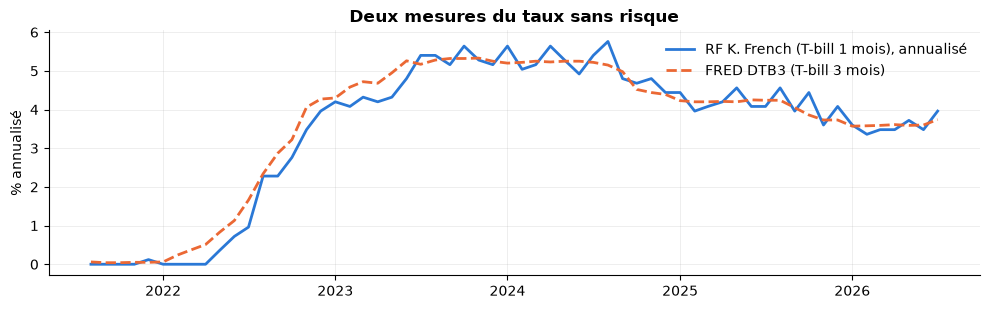

In [31]:
print(f"Corrélation RF (K. French) / RF_FRED : {data[['RF', 'RF_FRED']].corr().iloc[0, 1]:.3f} | "
      f"écart moyen : {(data['RF_FRED'] - data['RF']).mean() * 1e4:+.2f} pb/mois")
y_fred = data["r_fonds"] - data["RF_FRED"]
X_fred = sm.add_constant(data[FACTORS3].assign(MKT_RF=data["MKT"] - data["RF_FRED"]))
ff3_fred = sm.OLS(y_fred, X_fred).fit()

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(data.index.to_timestamp(), data["RF"] * 1200, color=COLORS["fonds"], label="RF K. French (T-bill 1 mois), annualisé")
ax.plot(data.index.to_timestamp(), data["RF_FRED"] * 1200, color=COLORS["marche"], ls="--", label="FRED DTB3 (T-bill 3 mois)")
ax.set(ylabel="% annualisé", title="Deux mesures du taux sans risque"); ax.legend()
plt.tight_layout(); plt.show()

### 10.2 Log-rendements vs rendements simples

Comme annoncé au §3.3, on ré-estime le modèle avec le **rendement simple** du fonds $R_{it} = P_t/P_{t-1} - 1$, cohérent
avec la construction (arithmétique) des facteurs de K. French. L'écart attendu sur l'alpha est d'environ
$\sigma_i^2 / 2$ par mois.

In [32]:
ff3_simple = sm.OLS(data["R_fonds_simple"] - data["RF"], X3).fit()
print(f"Écart attendu ≈ sigma²/2 = {data['r_fonds'].var() / 2:.4%} par mois ; "
      f"écart observé sur les rendements moyens = {(data['R_fonds_simple'] - data['r_fonds']).mean():.4%}")

rob = pd.DataFrame({
    "FF3 principal (log, RF French)": ff3.params, "p (principal)": ff3.pvalues,
    "FF3 RF = FRED DTB3": ff3_fred.params, "p (FRED)": ff3_fred.pvalues,
    "FF3 rendements simples": ff3_simple.params, "p (simples)": ff3_simple.pvalues,
})
rob.loc["alpha annualisé"] = [12 * ff3.params["const"], np.nan, 12 * ff3_fred.params["const"], np.nan,
                              12 * ff3_simple.params["const"], np.nan]
rob.loc["R² ajusté"] = [ff3.rsquared_adj, np.nan, ff3_fred.rsquared_adj, np.nan, ff3_simple.rsquared_adj, np.nan]
rob

Écart attendu ≈ sigma²/2 = 0.1425% par mois ; écart observé sur les rendements moyens = 0.1434%


,"FF3 principal (log, RF French)",p (principal),FF3 RF = FRED DTB3,p (FRED),FF3 rendements simples,p (simples)
const,-0.0023,0.2155,-0.0023,0.2168,-0.0010,0.6178
MKT_RF,1.0554,0.0000,1.0551,0.0000,1.0595,0.0000
SMB,-0.0983,0.1476,-0.0981,0.1481,-0.0999,0.1498
HML,-0.2453,0.0000,-0.2453,0.0000,-0.2415,0.0000
alpha annualisé,-0.0279,NaN,-0.0278,NaN,-0.0114,NaN
R² ajusté,0.9348,NaN,0.9348,NaN,0.9323,NaN


**10.1 — Taux sans risque FRED.** Les deux mesures sont corrélées à 0,99 et ne diffèrent en moyenne que de
0,7 point de base par mois. **Les résultats sont identiques** (alpha −2,78 %/an, p = 0,22). Le choix du taux sans
risque est sans conséquence ici.

**10.2 — Log-rendements vs rendements simples : un biais à connaître.** Avec des rendements simples, l'alpha passe à
**−0,10 %/mois (−1,1 %/an, p = 0,62)**, contre −0,23 %/mois avec les log-rendements. L'écart (≈ 0,13 point/mois) est très
proche de la prédiction théorique $\sigma_i^2/2 \approx 0{,}14$ %/mois. Les bêtas et le R² ne changent pratiquement pas.
**Près de 60 % de l'alpha négatif du modèle principal (1,7 point sur 2,8 par an) est donc un artefact mécanique**, dû au
mélange de log-rendements (pour le fonds) et de rendements arithmétiques (pour les facteurs de K. French).

**Conséquence.** La conclusion qualitative (**pas d'alpha significatif**) est robuste à tous ces choix. En revanche, pour
*chiffrer* la sous-performance, l'estimation la plus cohérente est celle en rendements simples : **environ −1 % par an**,
un ordre de grandeur comparable aux frais de gestion d'un fonds actif. Le fonds ferait donc à peu près aussi bien que
son portefeuille de facteurs **avant frais**.

In [33]:
# ============ SYNTHÈSE CHIFFRÉE ============
summary = pd.DataFrame({
    "coef": ff3.params, "p MCO": ff3.pvalues, "p HC1": ff3_hc1.pvalues,
}).rename(index={"const": "alpha (mensuel)", "MKT_RF": "bêta marché", "SMB": "bêta SMB (taille)", "HML": "bêta HML (style)"})
print(f"{FUND_NAME} ({TICKER}) - {first_p} à {last_p} - n = {n}")
print(f"Alpha annualisé : {12 * ff3.params['const']:+.2%} (p = {ff3.pvalues['const']:.3f}) | R² ajusté = {ff3.rsquared_adj:.3f}")
print(f"VIF max = {vif3['VIF'].max():.2f} | Breusch-Pagan p = {bp_p:.3f} | JB résidus p = {jb_res.pvalue:.3f} | "
      f"{len(influents)} mois influents (Cook)")
print(f"Carhart : beta_MOM = {carhart.params['MOM']:+.3f} (p = {carhart.pvalues['MOM']:.3f}), "
      f"ΔBIC = {carhart.bic - ff3.bic:+.2f}, ΔR²aj = {carhart.rsquared_adj - ff3.rsquared_adj:+.4f}")
summary

Fidelity Magellan Fund (FMAGX) - 2021-08 à 2026-07 - n = 60
Alpha annualisé : -2.79% (p = 0.216) | R² ajusté = 0.935
VIF max = 1.13 | Breusch-Pagan p = 0.550 | JB résidus p = 0.582 | 3 mois influents (Cook)
Carhart : beta_MOM = +0.104 (p = 0.019), ΔBIC = -1.93, ΔR²aj = +0.0052


,coef,p MCO,p HC1
alpha (mensuel),-0.0023,0.2155,0.2043
bêta marché,1.0554,0.0000,0.0000
bêta SMB (taille),-0.0983,0.1476,0.1361
bêta HML (style),-0.2453,0.0000,0.0000


## 11. Bilan critique

### 11.1 Réponse à la question posée

**La performance historique de FMAGX ne provient pas d'un talent de sélection démontrable.** Sur août 2021 – juillet 2026 :

1. **L'alpha de Jensen n'est pas significatif** (−2,8 %/an en log-rendements, −1,1 %/an en rendements simples,
   p > 0,2). Ce résultat est robuste à la correction de White (HC1), aux écarts-types de Newey–West, à l'exclusion des
   points influents, au choix du taux sans risque et à l'ajout du momentum. Son estimation ponctuelle est **négative sur
   toutes les spécifications et toutes les fenêtres glissantes**, et fortement négative sur la dernière année
   (−11,5 %/an hors échantillon).
2. **La performance s'explique presque entièrement par des expositions factorielles** (R² = 94 %) :
   * un **bêta de marché d'environ 1,05**, indiscernable de 1 ;
   * un **biais *growth* marqué et stable** (β_HML ≈ −0,25), qui a *coûté* environ 1,9 %/an sur une période favorable à la *value* ;
   * un **biais grandes capitalisations** probable mais fragile (β_SMB ≈ −0,10, significatif seulement hors mois atypiques) ;
   * une **légère exposition momentum** récente (β_MOM ≈ +0,10, faiblement justifiée).
3. **Pour un investisseur**, FMAGX se comporte comme un **portefeuille « large cap growth » à bêta 1**, que l'on peut
   répliquer à bas coût avec des ETF indiciels (marché + tilt *growth*). Sur la période, il a eu un ratio de Sharpe deux fois
   plus faible que le marché (0,29 contre 0,56). **Les frais de gestion active ne sont pas justifiés par les données.**
4. **Pour un sélectionneur de fonds**, le style est **cohérent et stable** (pas de dérive). En revanche, l'étiquette
   « large cap diversifié » masque un **biais *growth*** significatif, dont il faut tenir compte dans l'allocation
   globale (risque de concentration sur les valeurs de croissance).

### 11.2 Ce que le modèle ne capture pas : limites assumées

* **Faible puissance statistique.** Avec 60 mois, l'écart-type de l'alpha annualisé est d'environ 2,2 points. Pour détecter
  un alpha de +1 %/an avec $t = 2$, il faudrait un écart-type de 0,5 point, soit $60 \times (2{,}2/0{,}5)^2 \approx 1\,200$
  mois, **près d'un siècle de données** à volatilité résiduelle constante. « Alpha non significatif » signifie donc « pas
  de preuve de talent », **pas** « preuve d'absence de talent ».
* **Des facteurs non investissables et bruts de frais.** Les portefeuilles de K. French comportent des positions
  vendeuses, n'ont ni coûts de transaction ni frais, et sont rééquilibrés sans friction. Le fonds, lui, est mesuré
  **net de frais**. L'alpha compare donc un produit réel à un benchmark théorique, ce qui défavorise mécaniquement le fonds.
* **Le mélange log-rendements / rendements arithmétiques** biaise l'alpha d'environ −1,7 %/an (§10.2). C'est un
  point de méthode imposé par la consigne, que nous avons quantifié plutôt qu'ignoré.
* **Des bêtas supposés constants.** Les fenêtres glissantes montrent une bonne stabilité, mais un modèle linéaire à bêtas
  fixes ne capture ni un **market timing** du gérant (augmenter le bêta avant les hausses), ni un changement de
  comportement en **régime de stress**.
* **Des facteurs de risque omis.** Le style *growth* des grandes valeurs technologiques est fortement corrélé à la
  **rentabilité** (*profitability*) et à l'**investissement**, que FF3 n'inclut pas. Une partie de l'exposition HML
  négative pourrait en réalité refléter ces facteurs.
* **Un biais de sélection et une dépendance à la période.** FMAGX a été choisi parce qu'il est célèbre et existe toujours
  (biais du survivant). La fenêtre 2021–2026 est très particulière : krach des valeurs de croissance en 2022, rallye
  de l'IA ensuite, prime *value* positive. Les bêtas de style en dépendent.
* **La qualité des données Yahoo.** La VL ajustée dépend de la méthode d'ajustement de Yahoo Finance pour les
  distributions (qui fait varier la performance de 7,5 points par an, §4.3). Nous ne l'avons pas recoupée avec une source
  indépendante.

### 11.3 Pistes d'amélioration concrètes

1. **Passer au modèle à 5 facteurs de Fama–French (2015)** en ajoutant RMW (rentabilité) et CMA (investissement), disponibles
   dans la même bibliothèque (`F-F_Research_Data_5_Factors_2x3`), pour tester si le biais *growth* est en réalité un
   biais « grandes entreprises rentables » (*quality*).
2. **Tester le market timing** avec le modèle de **Treynor–Mazuy** (ajout de $(R_{mt}-R_{ft})^2$) ou de
   **Henriksson–Merton** (bêta différent en marché haussier et baissier). Un coefficient positif et significatif révélerait
   un talent de timing que l'alpha de Jensen ne mesure pas.
3. **Capturer le régime de marché** : interagir le bêta de marché avec une indicatrice de **forte volatilité implicite**
   (VIX au-dessus de sa médiane, série `VIXCLS` de la FRED), pour savoir si le fonds devient plus agressif en période de
   stress.
4. **Utiliser un benchmark investissable** en complément : régresser le fonds sur des ETF (SPY pour le marché, IWF − IWD
   pour growth − value, IWM − IWB pour small − large). L'alpha obtenu répond directement à la question de l'investisseur :
   « fais-tu mieux que les ETF que je pourrais acheter à la place ? ».
5. **Allonger l'historique** (10–20 ans, en contrôlant les changements de gérant du fonds par des sous-périodes ou un test
   de Chow) pour gagner en puissance.
6. **Évaluer la significativité de l'alpha par bootstrap** des résidus (à la Kosowski et al., 2006), pour ne pas
   dépendre de l'hypothèse de normalité en petit échantillon.
7. **Harmoniser les rendements** : estimer le modèle principal en rendements simples, ou convertir les facteurs en
   log ($\ln(1+F_t)$), pour supprimer le biais de $\sigma^2/2$ sur l'alpha.

## 12. Export pour le Projet 2

Le Projet 2 reprend les **résidus** $\hat\varepsilon_t$ du modèle retenu pour construire un modèle ARMA. On les exporte
avec les variables du modèle afin que les deux projets reposent exactement sur les mêmes données.

In [34]:
export = data[["r_fonds", "RF", "y"] + FACTORS4].copy()
export["resid_FF3"] = ff3.resid
export["resid_Carhart"] = carhart.resid
export["fitted_FF3"] = ff3.fittedvalues
export.index = export.index.to_timestamp(how="end").normalize()
export.index.name = "date_fin_de_mois"
export.to_csv(DATA_DIR / "projet1_donnees_et_residus.csv")
print("Fichiers présents dans", DATA_DIR.resolve())
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name:<42} {f.stat().st_size / 1024:6.1f} Ko")
export.tail(3)

Fichiers présents dans C:\Users\maxse\OneDrive\Documents\ecole\esilv\a3\CdF_Econometrie\Projet1_Fama_French_G5\data
  FF_Momentum_Factor_mensuel.csv                0.9 Ko
  FF_Research_Data_Factors_mensuel.csv          1.8 Ko
  FMAGX_quotidien.csv                          61.7 Ko
  FRED_DTB3_quotidien.csv                      22.1 Ko
  projet1_donnees_et_residus.csv               10.1 Ko


,r_fonds,RF,y,MKT_RF,SMB,HML,MOM,resid_FF3,resid_Carhart,fitted_FF3
date_fin_de_mois,,,,,,,,,,
2026-05-31,0.0284,0.0031,0.0253,0.0491,-0.0159,-0.0231,0.0139,-0.0314,-0.0321,0.0567
2026-06-30,0.0032,0.0029,0.0003,-0.0107,0.0339,0.0358,0.0462,0.0260,0.0204,-0.0257
2026-07-31,-0.0231,0.0033,-0.0264,-0.0060,-0.0196,0.0211,-0.1225,-0.0145,-0.0007,-0.0119
